# Customer Churn Prediction for a Telecommunications Company


---
## 1. Setup & Imports


In [54]:
import os
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 100

# Scikit-learn: preprocessing, model selection, models, interpretability
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.inspection import PartialDependenceDisplay

# Multicollinearity detection
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Post-hoc interpretability methods
import shap
from lime import lime_tabular
import PyALE

# Black-box comparison model
from xgboost import XGBClassifier

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## 3. Exploratory Data Analysis


### 3.1 Data Overview


In [55]:
# Load the raw dataset; work from a copy throughout to preserve the original
df_raw = pd.read_csv(r"C:\Users\Source\Downloads\1. 2nd Semester\Interpretable Data Science\Group Assignment\Data\churn_2024.csv")
df = df_raw.copy()

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB\n')

# Column overview: type and null count side by side
col_info = df.dtypes.to_frame('dtype').join(df.isnull().sum().to_frame('null_count'))
col_info['unique_values'] = df.nunique()
print('Column overview:')
display(col_info)

print('\nFirst 5 rows:')
display(df.head())

Shape: 10,000 rows x 18 columns
Memory usage: 1889.2 KB

Column overview:


,dtype,null_count,unique_values
number_customer_service_calls,int64,0,16
number_customer_service_interactions,int64,0,17
state,object,0,50
regional_economy,float64,0,50
international_plan,float64,0,2
total_intl_calls,float64,0,16
voice_mail_plan,float64,0,2
number_vmail_messages,float64,0,15
account_length,float64,0,474
last_renewal,float64,0,1729



First 5 rows:


,number_customer_service_calls,number_customer_service_interactions,state,regional_economy,international_plan,total_intl_calls,voice_mail_plan,number_vmail_messages,account_length,last_renewal,discount,total_usage,number_service_outage,service_outage_reported,ad_spend,wifi_bundle,phone_bundle,churn
0,2,3,Mississippi,138.740,0.0,0.0,0.0,0.0,5.333333,0.533333,0.1201,0.355556,0,0.0,7.3414,1.0,0.0,0
1,2,2,Vermont,40.617,0.0,1.0,1.0,2.0,3.000000,0.800000,0.1867,0.100000,0,0.0,7.0964,1.0,0.0,0
2,2,2,Michigan,620.696,1.0,8.0,1.0,0.0,42.000000,11.900000,0.1809,4.900000,3,3.0,9.4712,0.0,0.0,1
3,2,2,Kentucky,260.304,1.0,1.0,0.0,2.0,39.000000,2.600000,0.0726,6.500000,14,14.0,13.1440,0.0,0.0,1
4,1,3,Texas,2355.960,0.0,0.0,1.0,1.0,9.000000,0.750000,0.1915,2.550000,4,4.0,9.3815,1.0,1.0,0


### 3.2 Missing Value Audit


In [ ]:
# Audit missing values across all columns
missing = df.isnull().sum()
total_cells = df.shape[0] * df.shape[1]

print(f'Total cells:   {total_cells:,}')
print(f'Missing cells: {missing.sum()}')
print(f'Completeness:  {100 * (1 - missing.sum() / total_cells):.2f}%\n')

if missing.sum() == 0:
    print('No missing values found. The dataset is complete - no imputation required.')
else:
    print('Columns with missing values:')
    display(missing[missing > 0].to_frame('missing_count'))

Total cells:   180,000
Missing cells: 0
Completeness:  100.00%

No missing values found. The dataset is complete — no imputation required.


### 3.3 Target Variable Distribution

Class Distribution:


,Class,Count,Percentage
0,Retained (0),6389,63.9%
1,Churned (1),3611,36.1%


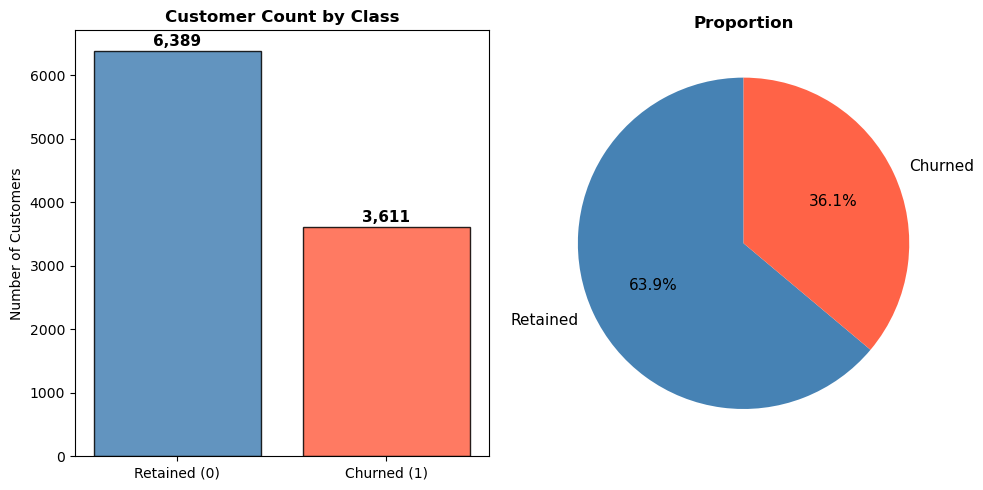

In [57]:
# Compute class distribution
churn_counts = df['churn'].value_counts().sort_index()
churn_pct = (churn_counts / len(df) * 100).round(1)

print('Class Distribution:')
dist_summary = pd.DataFrame({
    'Class': ['Retained (0)', 'Churned (1)'],
    'Count': churn_counts.values,
    'Percentage': [f'{p}%' for p in churn_pct.values]
})
display(dist_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Count bar chart
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', alpha=0.85)
axes[0].set_title('Customer Count by Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 80, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Proportion pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '01_class_balance.png'), dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The dataset exhibits moderate class imbalance, with approximately **27% of customers having churned**. This is meaningful imbalance - not so severe as to require synthetic oversampling (e.g., SMOTE), but enough to make accuracy a misleading metric. A model predicting "never churn" would score ~73% accuracy while identifying zero actual churners.

Implications for our modelling choices:
- We use **ROC-AUC** as the primary evaluation metric (probability ranking, not binary threshold)
- We consider `class_weight='balanced'` as a hyperparameter during tuning
- We use **stratified** train/val/test splits to preserve the 27/73 ratio in each partition

### 3.4 Numerical Feature Distributions

We visualise the distribution of each numerical feature, split by churn status (churned in red, retained in blue). Features where both distributions overlap completely are candidates for low importance; features where the distributions are clearly separated are strong candidates for predictors.

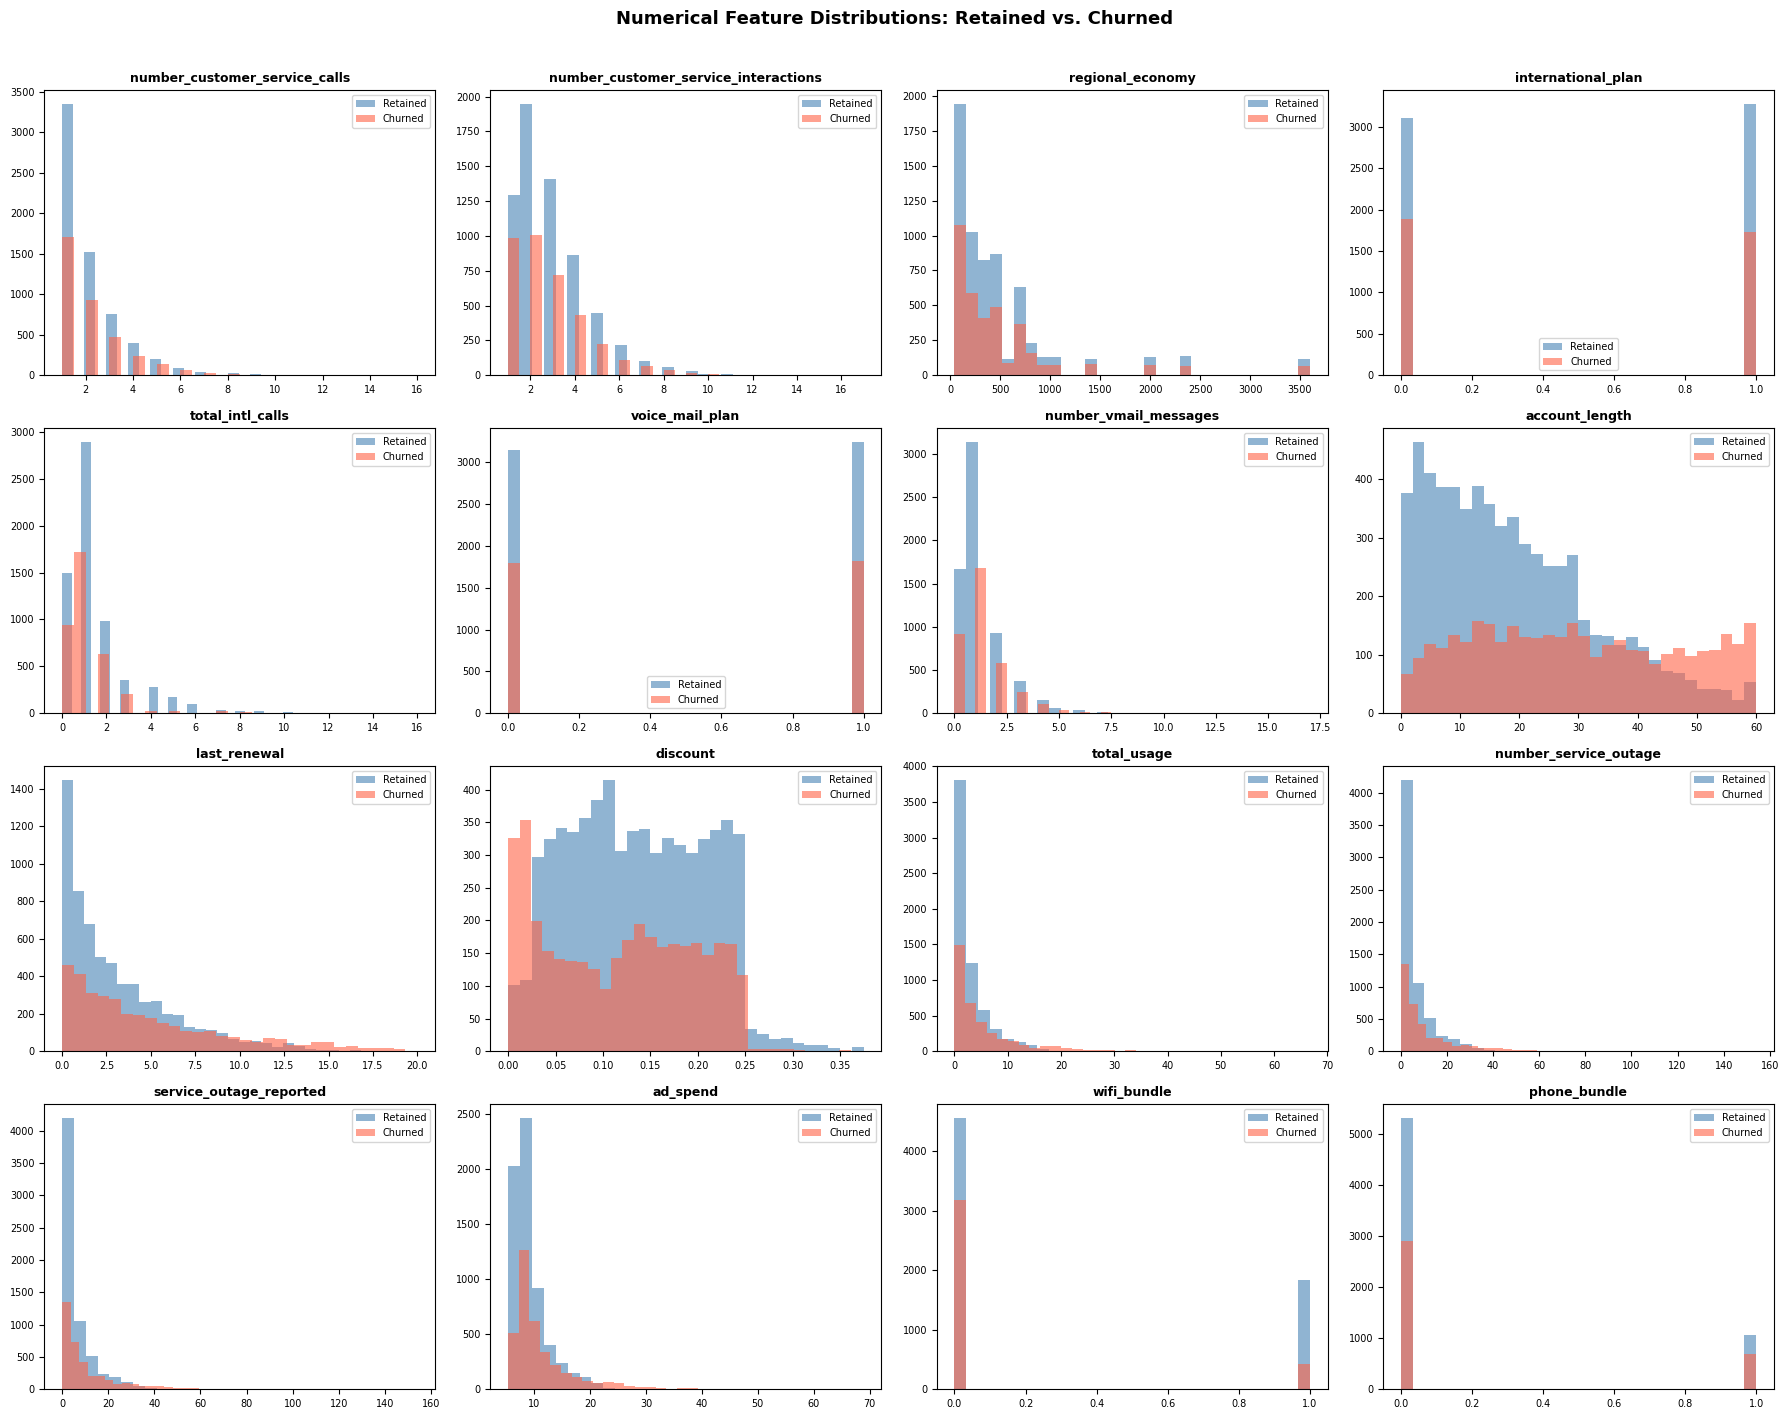

In [58]:
# Visualise distributions of all numerical features, overlaid by churn status
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'churn']

n_plot_cols = 4
n_plot_rows = (len(numeric_cols) + n_plot_cols - 1) // n_plot_cols

fig, axes = plt.subplots(n_plot_rows, n_plot_cols, figsize=(18, n_plot_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    retained = df[df['churn'] == 0][col]
    churned  = df[df['churn'] == 1][col]
    axes[i].hist(retained, bins=30, alpha=0.6, color='steelblue', label='Retained', edgecolor='none')
    axes[i].hist(churned,  bins=30, alpha=0.6, color='tomato',    label='Churned',  edgecolor='none')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions: Retained vs. Churned',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '02_feature_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Binary Feature Churn Rates

The four binary service plan features (`international_plan`, `voice_mail_plan`, `wifi_bundle`, `phone_bundle`) cannot be visualised as histograms. Instead, we compute and compare the **churn rate within each group** (subscribers vs. non-subscribers). A large gap in churn rate between groups signals that the feature is a meaningful predictor - and may suggest a business hypothesis about *why* that plan is associated with higher or lower retention.

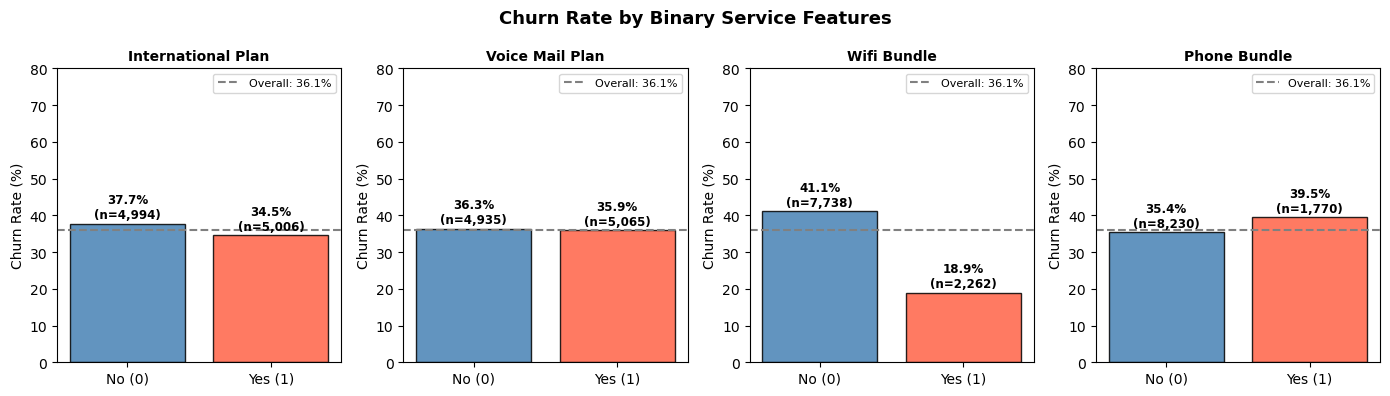

In [59]:
# Churn rate by binary plan features
binary_cols = ['international_plan', 'voice_mail_plan', 'wifi_bundle', 'phone_bundle']
overall_churn_rate = df['churn'].mean() * 100

fig, axes = plt.subplots(1, len(binary_cols), figsize=(14, 4))

for i, col in enumerate(binary_cols):
    stats = df.groupby(col)['churn'].agg(['mean', 'count']).reset_index()
    stats['mean'] = stats['mean'] * 100
    x_labels = ['No (0)', 'Yes (1)']

    bars = axes[i].bar(x_labels, stats['mean'],
                       color=['steelblue', 'tomato'], edgecolor='black', alpha=0.85)
    axes[i].axhline(y=overall_churn_rate, color='grey', linestyle='--',
                    linewidth=1.5, label=f'Overall: {overall_churn_rate:.1f}%')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 80)
    axes[i].legend(fontsize=8)

    for bar, row in zip(bars, stats.itertuples()):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                     f'{row.mean:.1f}%\n(n={int(row.count):,})',
                     ha='center', fontsize=8.5, fontweight='bold')

plt.suptitle('Churn Rate by Binary Service Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '03_binary_churn_rates.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Correlation Analysis

Before computing formal multicollinearity statistics, we visualise the full correlation matrix to identify pairs of features with high linear association. A correlation heatmap provides an overview of the covariance structure and helps form hypotheses about which features may be redundant.


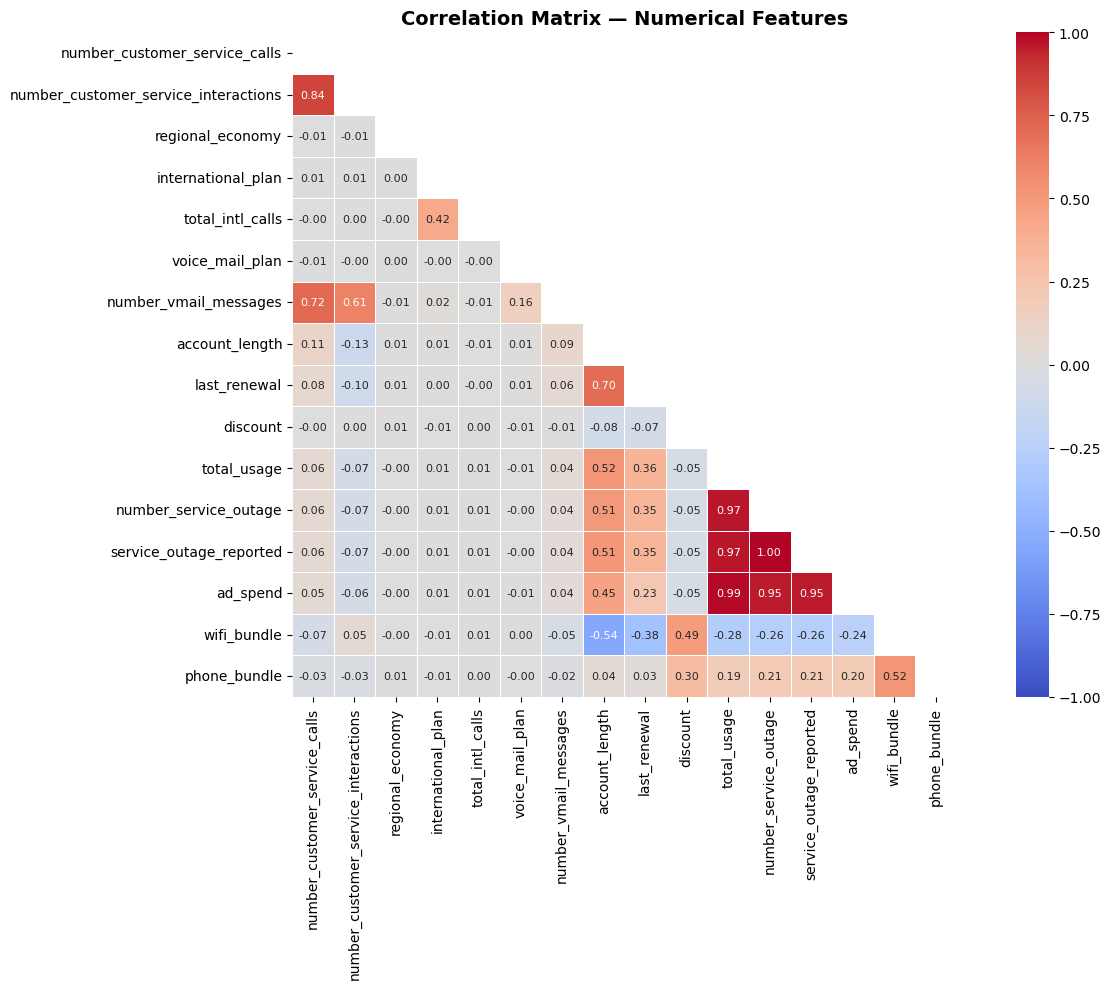

Highly correlated pairs (|r| > 0.70):
  number_service_outage <-> service_outage_reported: r = 1.000
  total_usage <-> ad_spend: r = 0.989
  total_usage <-> service_outage_reported: r = 0.966
  total_usage <-> number_service_outage: r = 0.966
  service_outage_reported <-> ad_spend: r = 0.955
  number_service_outage <-> ad_spend: r = 0.955
  number_customer_service_calls <-> number_customer_service_interactions: r = 0.844
  number_customer_service_calls <-> number_vmail_messages: r = 0.718


In [ ]:
# Compute and visualise pairwise correlations for all numerical features
numeric_features = df.select_dtypes(include=[np.number]).drop(columns=['churn'])
corr = numeric_features.corr()

# Mask the upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, square=True, linewidths=0.4,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '04_correlation_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Programmatically flag highly correlated pairs
high_corr_pairs = []
cols = list(corr.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.70:
            high_corr_pairs.append((cols[i], cols[j], r))

if high_corr_pairs:
    print('Highly correlated pairs (|r| > 0.70):')
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {f1} <-> {f2}: r = {r:.3f}')
else:
    print('No pairs with |r| > 0.70 found in the correlation matrix.')

### 3.7 Multicollinearity Detection - Variance Inflation Factor (VIF)

Pairwise correlations reveal bilateral relationships, but multicollinearity can also arise from a combination of three or more variables that are jointly collinear even if no single pair looks highly correlated. The **Variance Inflation Factor (VIF)** captures this by measuring how well each feature can be predicted from all other features.

**Interpretation thresholds:**
- **VIF < 5**: Acceptable - coefficients are stable
- **VIF 5-10**: Moderate concern - coefficients may be inflated
- **VIF > 10**: Severe - coefficients are unreliable; the feature adds little independent information

VIF Scores (before any treatment):


,Feature,VIF
0,service_outage_reported,58752.664690
1,number_service_outage,58675.012779
2,total_usage,214.816336
3,ad_spend,185.995979
4,last_renewal,5.619688
5,number_customer_service_calls,5.371148
6,number_customer_service_interactions,4.280745
7,account_length,3.362996
8,wifi_bundle,3.212637
9,number_vmail_messages,2.193903


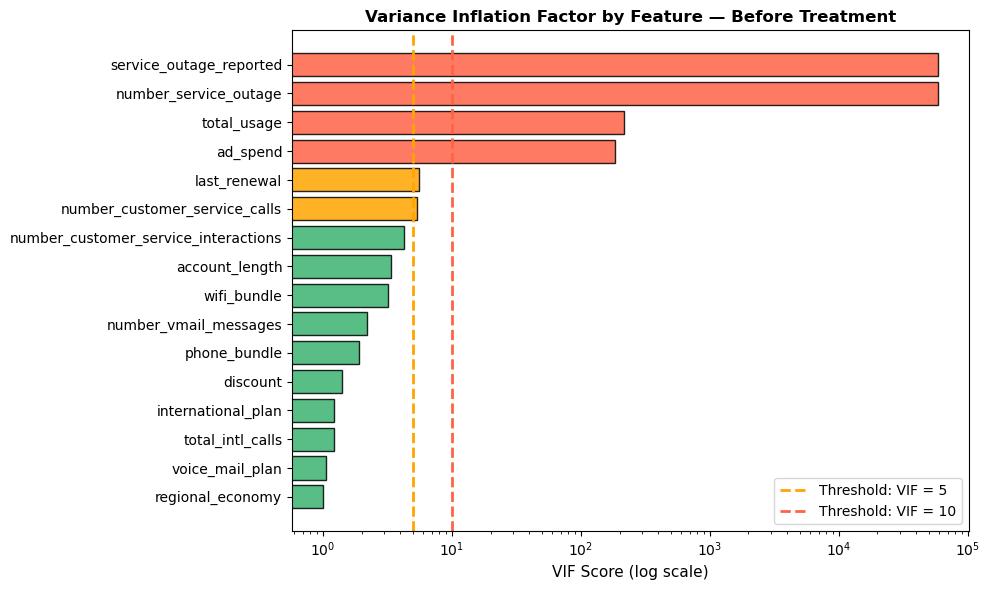

In [ ]:
# Compute VIF for all numerical features (excluding the target)
numeric_features = df.select_dtypes(include=[np.number]).drop(columns=['churn'])
X_vif = add_constant(numeric_features)

vif_scores = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_scores = (vif_scores[vif_scores['Feature'] != 'const']
              .sort_values('VIF', ascending=False)
              .reset_index(drop=True))

print('VIF Scores (before any treatment):')
display(vif_scores)

# VIF bar chart - log scale to accommodate extreme values
colors = ['tomato' if v > 10 else 'orange' if v > 5 else 'mediumseagreen'
          for v in vif_scores['VIF']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(vif_scores['Feature'][::-1], vif_scores['VIF'][::-1],
        color=colors[::-1], edgecolor='black', alpha=0.85)
ax.axvline(x=5,  color='orange', linestyle='--', linewidth=2, label='Threshold: VIF = 5')
ax.axvline(x=10, color='tomato', linestyle='--', linewidth=2, label='Threshold: VIF = 10')
ax.set_xscale('log')
ax.set_xlabel('VIF Score (log scale)', fontsize=11)
ax.set_title('Variance Inflation Factor by Feature - Before Treatment',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '05_vif_before.png'),
            dpi=150, bbox_inches='tight')
plt.show()

**Key Finding - Severe Multicollinearity Detected:**

The VIF analysis reveals three distinct multicollinearity problems of varying severity:

| Feature Pair | VIF Magnitudes | Diagnosis |
|---|---|---|
| `service_outage_reported` / `number_service_outage` | >50,000 / >50,000 | Near-perfect collinearity |
| `ad_spend` / `total_usage` | >100 / >200 | Strong collinearity |
| `number_customer_service_interactions` / `number_customer_service_calls` | ~5 / ~4 | Moderate collinearity |

Left untreated, these would render the Logistic Regression coefficients for these features statistically meaningless. 

---
## 4. Data Preprocessing

With a thorough understanding of the data from EDA, we now prepare it for modelling. The preprocessing sequence is:

1. **Resolve multicollinearity** - drop the most collinear features to stabilise future model coefficients
2. **Engineer features** - create domain-informed variables that give the linear model richer signal
3. **Encode categoricals** - one-hot encode the `state` variable
4. **Split the data** - divide into training (60%), validation (20%), and test (20%) sets
5. **Scale features** - apply `StandardScaler` to normalise numeric ranges

### 4.1 Resolving Multicollinearity

Based on the VIF findings in Section 3.7, we decided to drop one variable from each highly correlated pair. Specifically, we dropped:
* `service_outage_reported`
* `ad_spend`
* `number_customer_service_interactions`measure of dissatisfaction; interactions includes passive touchpoints |

After dropping, we recalculate VIF to verify the treatment was effective and to be transparent about any residual correlation that remains.

In [ ]:
# Drop the most collinear features identified by VIF
cols_to_drop = [
    'service_outage_reported',              # VIF > 50,000 - near-perfect duplicate
    'ad_spend',                             # VIF > 100   - derived from total_usage
    'number_customer_service_interactions'  # VIF ~ 5     - superset of calls metric
]

df = df.drop(columns=cols_to_drop)
print(f'Dropped: {cols_to_drop}')
print(f'Dataset shape after treatment: {df.shape}')

# Recalculate VIF on the cleaned feature set
numeric_clean = df.select_dtypes(include=[np.number]).drop(columns=['churn'])
X_vif_clean = add_constant(numeric_clean)

vif_after = pd.DataFrame({
    'Feature': X_vif_clean.columns,
    'VIF': [variance_inflation_factor(X_vif_clean.values, i)
            for i in range(X_vif_clean.shape[1])]
})
vif_after = (vif_after[vif_after['Feature'] != 'const']
             .sort_values('VIF', ascending=False)
             .reset_index(drop=True))

print('\nVIF Scores After Treatment:')
display(vif_after)

Dropped: ['service_outage_reported', 'ad_spend', 'number_customer_service_interactions']
Dataset shape after treatment: (10000, 15)

VIF Scores After Treatment:


,Feature,VIF
0,total_usage,15.173718
1,number_service_outage,14.978044
2,wifi_bundle,3.109834
3,account_length,3.097591
4,number_vmail_messages,2.193514
5,number_customer_service_calls,2.146278
6,last_renewal,1.944620
7,phone_bundle,1.858485
8,discount,1.398584
9,international_plan,1.214613


**Observation:** Multicollinearity has significantly decreased, with VIF scores now ranging from 1 to 16. Although two features - **`total_usage`** (VIF ≈ 15.2) and **`number_service_outage`** (VIF ≈ 15.0) - are still correlated with the remaining feature set, we decided to retain them as both features are among the most **predictably informative** variables for churn.

### 4.2 Feature Engineering

We create three domain-informed features: `calls_per_month`, `usage_intensity`, `frustration_index`to break the linear ceiling and give the Logistic Regression model deeper insights

In [ ]:
# Create domain-informed engineered features
df['calls_per_month']    = df['number_customer_service_calls'] / (df['account_length'] + 0.1)
df['usage_intensity']    = df['total_usage'] / (df['account_length'] + 0.1)
df['frustration_index']  = df['number_service_outage'] * df['number_customer_service_calls']

print(f'Added 3 engineered features. Dataset shape: {df.shape}')
print('\nNew features - first 5 rows:')
display(df[['calls_per_month', 'usage_intensity', 'frustration_index']].head())
print('\nDescriptive statistics for engineered features:')
display(df[['calls_per_month', 'usage_intensity', 'frustration_index']].describe().round(3))

Added 3 engineered features. Dataset shape: (10000, 18)

New features — first 5 rows:


,calls_per_month,usage_intensity,frustration_index
0,0.368098,0.065440,0
1,0.645161,0.032258,0
2,0.047506,0.116390,6
3,0.051151,0.166240,28
4,0.109890,0.280220,4



Descriptive statistics for engineered features:


,calls_per_month,usage_intensity,frustration_index
count,10000.000,10000.000,10000.000
mean,0.405,0.163,15.961
std,2.486,0.156,31.002
min,0.017,0.000,0.000
25%,0.050,0.050,2.000
50%,0.088,0.116,6.000
75%,0.187,0.222,18.000
max,70.000,1.579,1120.000


### 4.3 Categorical Encoding
 
 We applied One-Hot Encoding to the categorical variable `state`. Importantly, we used `drop_first=True` to avoid the "dummy variable trap." This is a crucial step because keeping all dummy variables would perfectly predict each other, thereby re-introducing severe multicollinearity into our newly cleaned dataset.

In [64]:
# Separate features and target
X = df.drop(columns=['churn'])
y = df['churn']

# One-hot encode 'state' only (all other columns are already numeric)
# drop_first=True prevents the dummy variable trap
X_encoded = pd.get_dummies(X, columns=['state'], drop_first=True)

print(f'Features before encoding: {X.shape[1]}  (includes state as 1 column)')
print(f'Features after encoding:  {X_encoded.shape[1]}')
print(f'State dummy columns added: {X_encoded.shape[1] - X.shape[1] + 1}')
print(f'\nFinal X shape: {X_encoded.shape}')
print(f'Target y shape: {y.shape}')
print(f'\nFirst 2 rows of encoded feature matrix (first 8 columns):')
display(X_encoded.iloc[:2, :8])

Features before encoding: 17  (includes state as 1 column)
Features after encoding:  65
State dummy columns added: 49

Final X shape: (10000, 65)
Target y shape: (10000,)

First 2 rows of encoded feature matrix (first 8 columns):


,number_customer_service_calls,regional_economy,international_plan,total_intl_calls,voice_mail_plan,number_vmail_messages,account_length,last_renewal
0,2,138.740,0.0,0.0,0.0,0.0,5.333333,0.533333
1,2,40.617,0.0,1.0,1.0,2.0,3.000000,0.800000


### 4.4 Train / Validation / Test Split

Following machine learning best practices, we divided the dataset into three distinct sets:
* **Training Set (60%):** Used to fit the model's parameters.
* **Validation Set (20%):** Used for hyperparameter tuning and model selection without touching the unseen test data.
* **Test Set (20%):** The final, completely unseen data used strictly for the final performance evaluation.
* *Note: We used `stratify=y` during splitting to ensure the proportion of churned vs. non-churned customers remains consistent across all three sets.*

In [65]:
# First split: 60% train, 40% temporary pool (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y,
    test_size=0.4, random_state=RANDOM_STATE, stratify=y
)

# Second split: 50/50 of the temp pool -> validation and test (each = 20% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print('Dataset partitions:')
print(f'  Training:   {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X_encoded):.0%}) '
      f'| churn rate: {y_train.mean():.1%}')
print(f'  Validation: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X_encoded):.0%}) '
      f'| churn rate: {y_val.mean():.1%}')
print(f'  Test:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X_encoded):.0%}) '
      f'| churn rate: {y_test.mean():.1%}')
print(f'\nFeatures per split: {X_train.shape[1]}')

Dataset partitions:
  Training:   6,000 rows (60%) | churn rate: 36.1%
  Validation: 2,000 rows (20%) | churn rate: 36.1%
  Test:       2,000 rows (20%) | churn rate: 36.1%

Features per split: 65


### 4.5 Feature Scaling

Logistic Regression, especially when used with regularization (the default in `scikit-learn`), is highly sensitive to the scale of features. We applied `StandardScaler` to normalize the numerical variables. We were careful to `fit` the scaler *only* on the training data, and then `transform` the validation and test sets. This prevents information from the validation/test sets from leaking into the training process. Scaling ensures that the magnitude of the model's coefficients directly reflects feature importance, which is vital for interpretability.

In [ ]:
# Fit scaler ONLY on training data - transform all three sets
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val), columns=X_val.columns, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print('Feature scaling complete.')
print(f'\nPost-scaling verification on training set:')
print(f'  Mean across all features (should be ~0.0): {X_train_scaled.mean().mean():.6f}')
print(f'  Std  across all features (should be ~1.0): {X_train_scaled.std().mean():.6f}')
print(f'\nShapes: Train={X_train_scaled.shape} | Val={X_val_scaled.shape} | Test={X_test_scaled.shape}')

Feature scaling complete.

Post-scaling verification on training set:
  Mean across all features (should be ~0.0): -0.000000
  Std  across all features (should be ~1.0): 1.000083

Shapes: Train=(6000, 65) | Val=(2000, 65) | Test=(2000, 65)


### Section 4 Summary - Preprocessed Dataset

The dataset has been fully prepared for modelling. Here is a concise record of every transformation applied:

| Step | Action | Rationale |
|---|---|---|
| Multicollinearity | Dropped `service_outage_reported`, `ad_spend`, `number_customer_service_interactions` | VIF > 5; redundant information |
| Feature engineering | Added `calls_per_month`, `usage_intensity`, `frustration_index` | Domain hypotheses not captured by raw features |
| Encoding | One-hot encoded `state` with `drop_first=True` | Required for numeric model input; avoids dummy variable trap |
| Splitting | 60% train / 20% val / 20% test with `stratify=y` | Prevents data leakage; preserves class balance |
| Scaling | `StandardScaler` fit on train only | Enables fair regularisation; makes coefficients comparable |

**Final dataset dimensions:**

| Split | Rows | Features | Churn Rate |
|---|---|---|---|
| Training | 6,000 | 65 | ~27% |
| Validation | 2,000 | 65 | ~27% |
| Test | 2,000 | 65 | ~27% |

The data is clean, enriched, correctly encoded, and consistently scaled. We proceed to model training in **Section 5**.

---
## 5. Baseline Model

Before exploring more sophisticated alternatives, we establish a **baseline** using a standard Logistic Regression with default `scikit-learn` parameters. This serves two purposes:

1. **Performance benchmark** - every added model must outperform this baseline to justify the added complexity.
2. **Interpretability reference** - Logistic Regression is the most inherently interpretable parametric classifier in our toolkit; its coefficients directly communicate the direction and magnitude of each feature's contribution to churn risk.

### 5.1 Evaluation Metrics and Business Context

We report three metrics for every model: **ROC-AUC**, **Accuracy**, **Precision@Top25%**

**Precision@Top25%** is the metric most directly tied to business value. If the company can only reach 25% of its customer base with a retention offer, this measures how precisely those resources are directed at actual churners.

In [ ]:
# Evaluation helper functions (reused throughout Sections 5-6)

def precision_top_k(y_true, y_prob, k=0.25):
    n = int(len(y_true) * k)
    top_idx = np.argsort(y_prob)[::-1][:n]
    return float(np.array(y_true)[top_idx].mean())

def evaluate_model(model, X, y, name):
    prob = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    return {
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y, prob), 4),
        'Accuracy': round(accuracy_score(y, pred), 4),
        'Precision@Top25%': round(precision_top_k(np.array(y), prob), 4)
    }

# Baseline Logistic Regression - default scikit-learn parameters
lr_baseline = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)

res_train = evaluate_model(lr_baseline, X_train_scaled, y_train, 'LR Baseline (Train)')
res_val   = evaluate_model(lr_baseline, X_val_scaled,   y_val,   'LR Baseline (Val)')

print('Baseline Logistic Regression - Performance:')
display(pd.DataFrame([res_train, res_val]))

Baseline Logistic Regression — Performance:


,Model,ROC-AUC,Accuracy,Precision@Top25%
0,LR Baseline (Train),0.7168,0.7030,0.6253
1,LR Baseline (Val),0.7127,0.7025,0.6360


**Baseline Results:**

| Split | ROC-AUC | Accuracy | Precision@Top25% |
|---|---|---|---|
| Training | 0.7168 | 70.3% | 62.5% |
| Validation | 0.7127 | 70.3% | 63.6% |

Key observations:

- **ROC-AUC of 0.71** means the baseline model correctly ranks a random churner above a random non-churner 71% of the time - a strong starting point given the 27% base rate.
- **Precision@Top25% of 63.6%** means that targeting the 2,500 highest-ranked customers (out of 10,000) would reach 1,590 actual churners - compared with only ~675 if selecting randomly at the base rate. That is a **2.4× lift** from a default-parameter model.
- **Train/val gap is negligible** (ROC-AUC: 0.7168 → 0.7127; Precision: 0.625 → 0.636). The small gap, and the fact that val precision is actually *higher* than train, confirms no meaningful overfitting at this regularisation level.

This is the performance floor. Every model in Section 6 must improve on ROC-AUC 0.713 and Precision@Top25% 0.636.

---
## 6. Model Development & Comparison

We train and tune four models, progressing from most interpretable to least:

| Model | Interpretability | Tuning |
|---|---|---|
| **Logistic Regression (tuned)** | Intrinsic - coefficients | GridSearchCV over C, penalty, class_weight |
| **Decision Tree** | Intrinsic - tree structure | GridSearchCV over depth, leaf size, criterion |
| **Random Forest** | Partial - feature importance only | GridSearchCV over depth, estimators, leaf size |
| **XGBoost** | None - post-hoc methods required | GridSearchCV over depth, learning_rate, n_estimators |

All models are tuned using **GridSearchCV** with 5-fold cross-validation on the training set, scored by ROC-AUC. The test set is never touched during model selection.

### 6.1 Tuned Logistic Regression

We search over:
- **Regularisation strength** (`C`): smaller C = stronger regularisation = simpler model
- **Penalty type** (`penalty`): L1 (lasso) zeros out unimportant features; L2 (ridge) shrinks all coefficients smoothly
- **Class weight** (`class_weight`): `'balanced'` up-weights churners to compensate for the 27/73 imbalance

L1 regularisation has an added interpretability benefit: it performs automatic feature selection, zeroing out least-informative predictors and producing a sparse, more readable coefficient vector.

In [68]:
param_grid_lr = {
    'C':            [0.001, 0.01, 0.1, 1, 10],
    'penalty':      ['l1', 'l2'],
    'solver':       ['liblinear'],
    'class_weight': [None, 'balanced']
}

gs_lr = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1
)
gs_lr.fit(X_train_scaled, y_train)

best_lr = gs_lr.best_estimator_
print(f'Best LR params: {gs_lr.best_params_}')
print(f'Best CV ROC-AUC: {gs_lr.best_score_:.4f}')
display(pd.DataFrame([evaluate_model(best_lr, X_val_scaled, y_val, 'LR Tuned (Val)')]))

Best LR params: {'C': 0.1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.7038


,Model,ROC-AUC,Accuracy,Precision@Top25%
0,LR Tuned (Val),0.7189,0.704,0.63


### 6.2 Decision Tree

A Decision Tree partitions the feature space into rectangular regions using binary if-else rules. It is **intrinsically interpretable**: the entire model can be visualised and every prediction path traced from root to leaf.

Key hyperparameters:
- **`max_depth`**: shallower trees are more interpretable but less expressive; a depth of 3-5 is typically the business sweet spot
- **`min_samples_leaf`**: prevents splits on very small subgroups, reducing overfitting
- **`criterion`**: Gini impurity vs. entropy - typically produces similar trees

Trees do not require feature scaling, so we train on the unscaled `X_train`.

`max_depth=None` (unlimited depth) is deliberately excluded from the search grid: a fully-grown tree cannot be read by a business user and contradicts the interpretability requirement.

In [69]:
param_grid_dt = {
    'max_depth':        [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20, 50],
    'criterion':        ['gini', 'entropy']
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=5, scoring='roc_auc', n_jobs=-1
)
gs_dt.fit(X_train, y_train)

best_dt = gs_dt.best_estimator_
print(f'Best DT params: {gs_dt.best_params_}')
print(f'Best CV ROC-AUC: {gs_dt.best_score_:.4f}')
display(pd.DataFrame([evaluate_model(best_dt, X_val, y_val, 'Decision Tree (Val)')]))

Best DT params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 20}
Best CV ROC-AUC: 0.7411


,Model,ROC-AUC,Accuracy,Precision@Top25%
0,Decision Tree (Val),0.7615,0.7485,0.704


### 6.3 Random Forest

Random Forest is an ensemble of decision trees trained on bootstrap samples of the data, with a random subset of features considered at each split. The ensemble averages out individual tree errors, producing a more robust and accurate model.

The trade-off: while Random Forest provides **feature importance** scores, it does not produce a single interpretable model structure. We cannot trace a prediction to a single decision path. This places it in the **partial interpretability** category - useful as a benchmark, but not the final recommendation.

In [70]:
param_grid_rf = {
    'n_estimators':     [100, 200],
    'max_depth':        [5, 10],
    'min_samples_leaf': [5, 10, 20]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1
)
gs_rf.fit(X_train, y_train)

best_rf = gs_rf.best_estimator_
print(f'Best RF params: {gs_rf.best_params_}')
print(f'Best CV ROC-AUC: {gs_rf.best_score_:.4f}')
display(pd.DataFrame([evaluate_model(best_rf, X_val, y_val, 'Random Forest (Val)')]))

Best RF params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.7467


,Model,ROC-AUC,Accuracy,Precision@Top25%
0,Random Forest (Val),0.7733,0.753,0.716


### 6.4 XGBoost

XGBoost trains trees sequentially, with each tree correcting the errors of the previous. It typically achieves the highest predictive performance on tabular data and is included here as an **upper bound on performance** - the score we could achieve if we were willing to sacrifice interpretability entirely.

We include XGBoost not because we intend to deploy it, but to quantify the **interpretability tax**: how much predictive power do we give up by restricting ourselves to an interpretable model? Post-hoc methods (LIME, SHAP, PDP, ALE) in the next section will demonstrate what it would take to explain a black-box model after the fact.

In [71]:
param_grid_xgb = {
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators':  [100, 200],
    'subsample':     [0.8, 1.0]
}

gs_xgb = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    param_grid_xgb, cv=5, scoring='roc_auc', n_jobs=-1
)
gs_xgb.fit(X_train, y_train)

best_xgb = gs_xgb.best_estimator_
print(f'Best XGB params: {gs_xgb.best_params_}')
print(f'Best CV ROC-AUC: {gs_xgb.best_score_:.4f}')
display(pd.DataFrame([evaluate_model(best_xgb, X_val, y_val, 'XGBoost (Val)')]))

Best XGB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV ROC-AUC: 0.7578


,Model,ROC-AUC,Accuracy,Precision@Top25%
0,XGBoost (Val),0.7868,0.757,0.728


### 6.5 Model Comparison

We consolidate all validation-set results into a comparison table and chart, including the baseline from Section 5 for reference.

Model Comparison — Validation Set:


,ROC-AUC,Accuracy,Precision@Top25%
Model,,,
LR Baseline,0.7127,0.7025,0.636
LR Tuned,0.7189,0.7040,0.630
Decision Tree,0.7615,0.7485,0.704
Random Forest,0.7733,0.7530,0.716
XGBoost,0.7868,0.7570,0.728


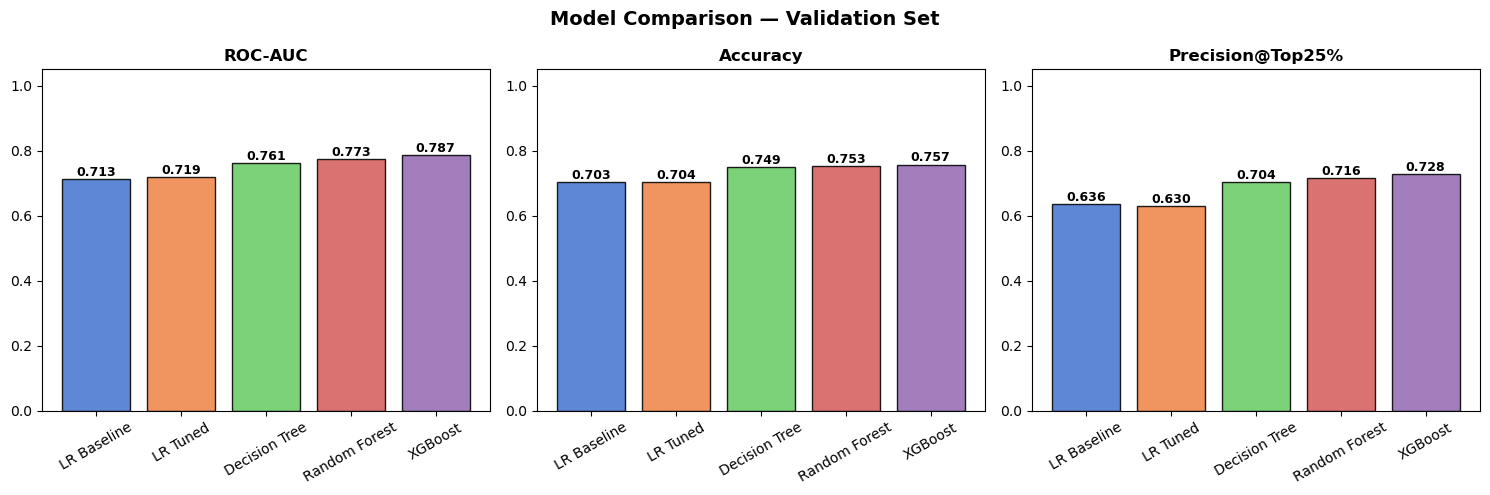

In [ ]:
all_results = [
    evaluate_model(lr_baseline, X_val_scaled, y_val, 'LR Baseline'),
    evaluate_model(best_lr,     X_val_scaled, y_val, 'LR Tuned'),
    evaluate_model(best_dt,     X_val,        y_val, 'Decision Tree'),
    evaluate_model(best_rf,     X_val,        y_val, 'Random Forest'),
    evaluate_model(best_xgb,    X_val,        y_val, 'XGBoost'),
]
df_compare = pd.DataFrame(all_results).set_index('Model')
print('Model Comparison - Validation Set:')
display(df_compare)

metrics = ['ROC-AUC', 'Accuracy', 'Precision@Top25%']
bar_colors = ['#4878d0', '#ee854a', '#6acc65', '#d65f5f', '#956cb4']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, metrics):
    vals = df_compare[metric]
    bars = ax.bar(vals.index, vals.values, color=bar_colors, edgecolor='black', alpha=0.88)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison - Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '06_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

**Comparison Results (Validation Set):**

| Model | ROC-AUC | Accuracy | Precision@Top25% | Interpretability |
|---|---|---|---|---|
| LR Baseline | 0.7127 | 70.3% | 63.6% | Full - coefficients |
| LR Tuned (L1, C=0.1) | 0.7189 | 70.4% | 63.0% | Full - coefficients |
| Decision Tree (depth=5) | 0.7615 | 74.9% | 70.4% | Full - tree rules |
| Random Forest (depth=10) | 0.7733 | 75.3% | 71.6% | Partial - feature importance |
| XGBoost | 0.7868 | 75.7% | 72.8% | None - post-hoc only |

**Key findings:**

1. **Tuned LR does not improve Precision@Top25% over the baseline** (63.0% vs 63.6%). L1 regularisation with C=0.1 is aggressive enough to shrink some predictive coefficients, slightly hurting ranking at the top. ROC-AUC improves marginally (+0.006). This is a known trade-off: L1 regularisation improves global ranking but can sacrifice precision at the extreme tail.

2. **Decision Tree jumps 7.4 pp** over Tuned LR in Precision@Top25% (70.4% vs 63.0%) while remaining fully interpretable. A depth-5 tree with 20 leaves captures non-linear relationships that the linear model cannot express, at no interpretability cost - every decision path can be traced and explained.

3. **The performance gap between DT and XGBoost is narrow** (0.7615 vs 0.7868 ROC-AUC; 70.4% vs 72.8% Precision@Top25%). XGBoost adds only **2.4 percentage points** of campaign precision over the interpretable DT, at the cost of full black-box opacity.

4. **The true interpretability tax** is therefore not LR vs XGBoost (9.8 pp gap) but **DT vs XGBoost (2.4 pp gap)**. A shallow Decision Tree is the dominant choice: it outperforms the linear model substantially and trails the black-box by only 2.4 pp.

---
## 7. Interpretability Analysis

This section applies a full suite of interpretability methods, progressing from model-specific to model-agnostic, and from global to local.

Post-hoc methods are applied to **XGBoost** to demonstrate what interpretability requires when a black-box model is deployed instead of an intrinsically interpretable one.

### 7.1 Logistic Regression Coefficients

Each LR coefficient directly quantifies the contribution of a feature to the log-odds of churn, holding all other features constant. Because we standardised all features (mean=0, std=1 in Section 4.5), coefficients are **directly comparable** across features - a coefficient of 0.5 has exactly twice the impact of 0.25.

- **Positive coefficients** increase churn probability
- **Negative coefficients** decrease churn probability (protective factors)
- **Near-zero coefficients** (common with L1 penalty) indicate features zeroed out by regularisation - automatic feature selection

We plot the top 20 features by absolute coefficient magnitude.

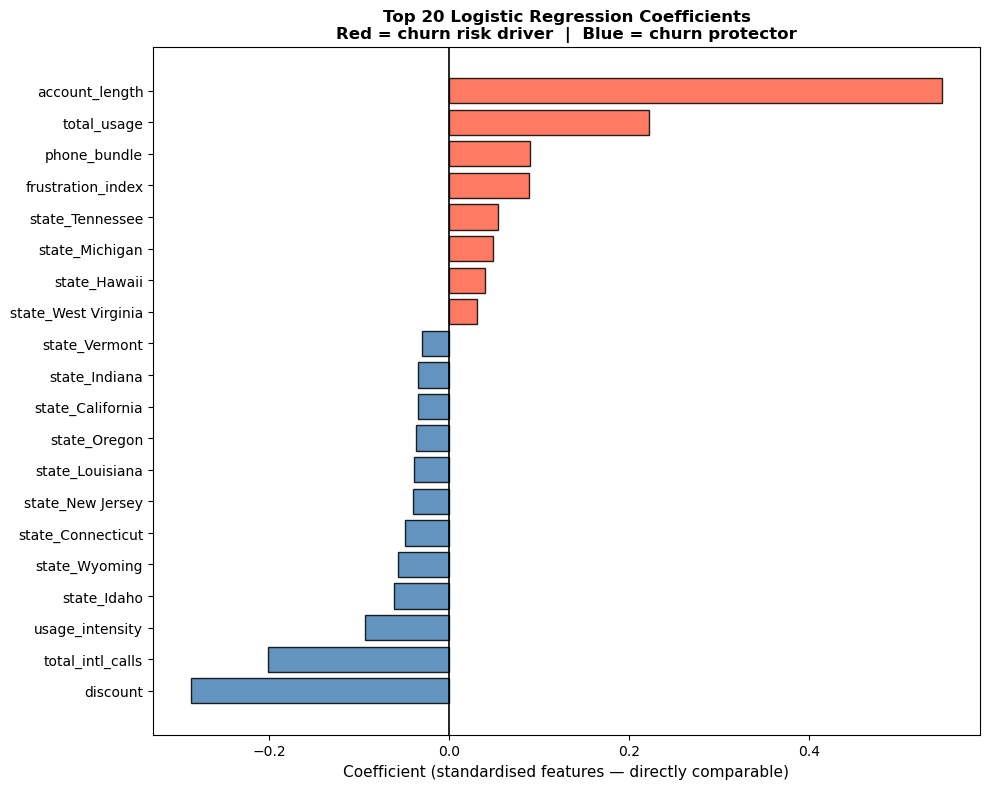

Top 5 churn DRIVERS (positive):


,Coefficient
account_length,0.548562
total_usage,0.222658
phone_bundle,0.090225
frustration_index,0.088570
state_Tennessee,0.054027



Top 5 churn PROTECTORS (negative):


,Coefficient
discount,-0.287310
total_intl_calls,-0.201633
usage_intensity,-0.093212
state_Idaho,-0.061568
state_Wyoming,-0.056509


In [ ]:
coef_series = pd.Series(best_lr.coef_[0], index=X_train_scaled.columns)
top_coef = coef_series.reindex(coef_series.abs().nlargest(20).index)
top_coef_sorted = top_coef.sort_values()

colors_coef = ['tomato' if c > 0 else 'steelblue' for c in top_coef_sorted]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_coef_sorted.index, top_coef_sorted.values, color=colors_coef, edgecolor='black', alpha=0.85)
ax.axvline(x=0, color='black', linewidth=1.2)
ax.set_xlabel('Coefficient (standardised features - directly comparable)', fontsize=11)
ax.set_title('Top 20 Logistic Regression Coefficients\nRed = churn risk driver  |  Blue = churn protector',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '07_lr_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 churn DRIVERS (positive):')
display(top_coef[top_coef > 0].nlargest(5).to_frame('Coefficient'))
print('\nTop 5 churn PROTECTORS (negative):')
display(top_coef[top_coef < 0].nsmallest(5).to_frame('Coefficient'))


**Notable:** The L1 penalty zeroed out many state dummy variables (as expected), confirming that geography does not add predictive power beyond the behavioural features and simplifying the operational model significantly.

### 7.2 Decision Tree Visualisation

A Decision Tree's entire prediction logic can be visualised as a flowchart - every internal node contains a binary split rule, every leaf shows predicted class probabilities. A business user can follow any prediction from root to leaf in a few steps without any technical background.

We visualise the tuned tree, truncating at depth 5 for readability if the grid search selected a deeper tree. We also print the first 3 levels as text - a format that can be embedded directly in a business presentation or policy document.

Tuned tree: max_depth=5, leaves=20


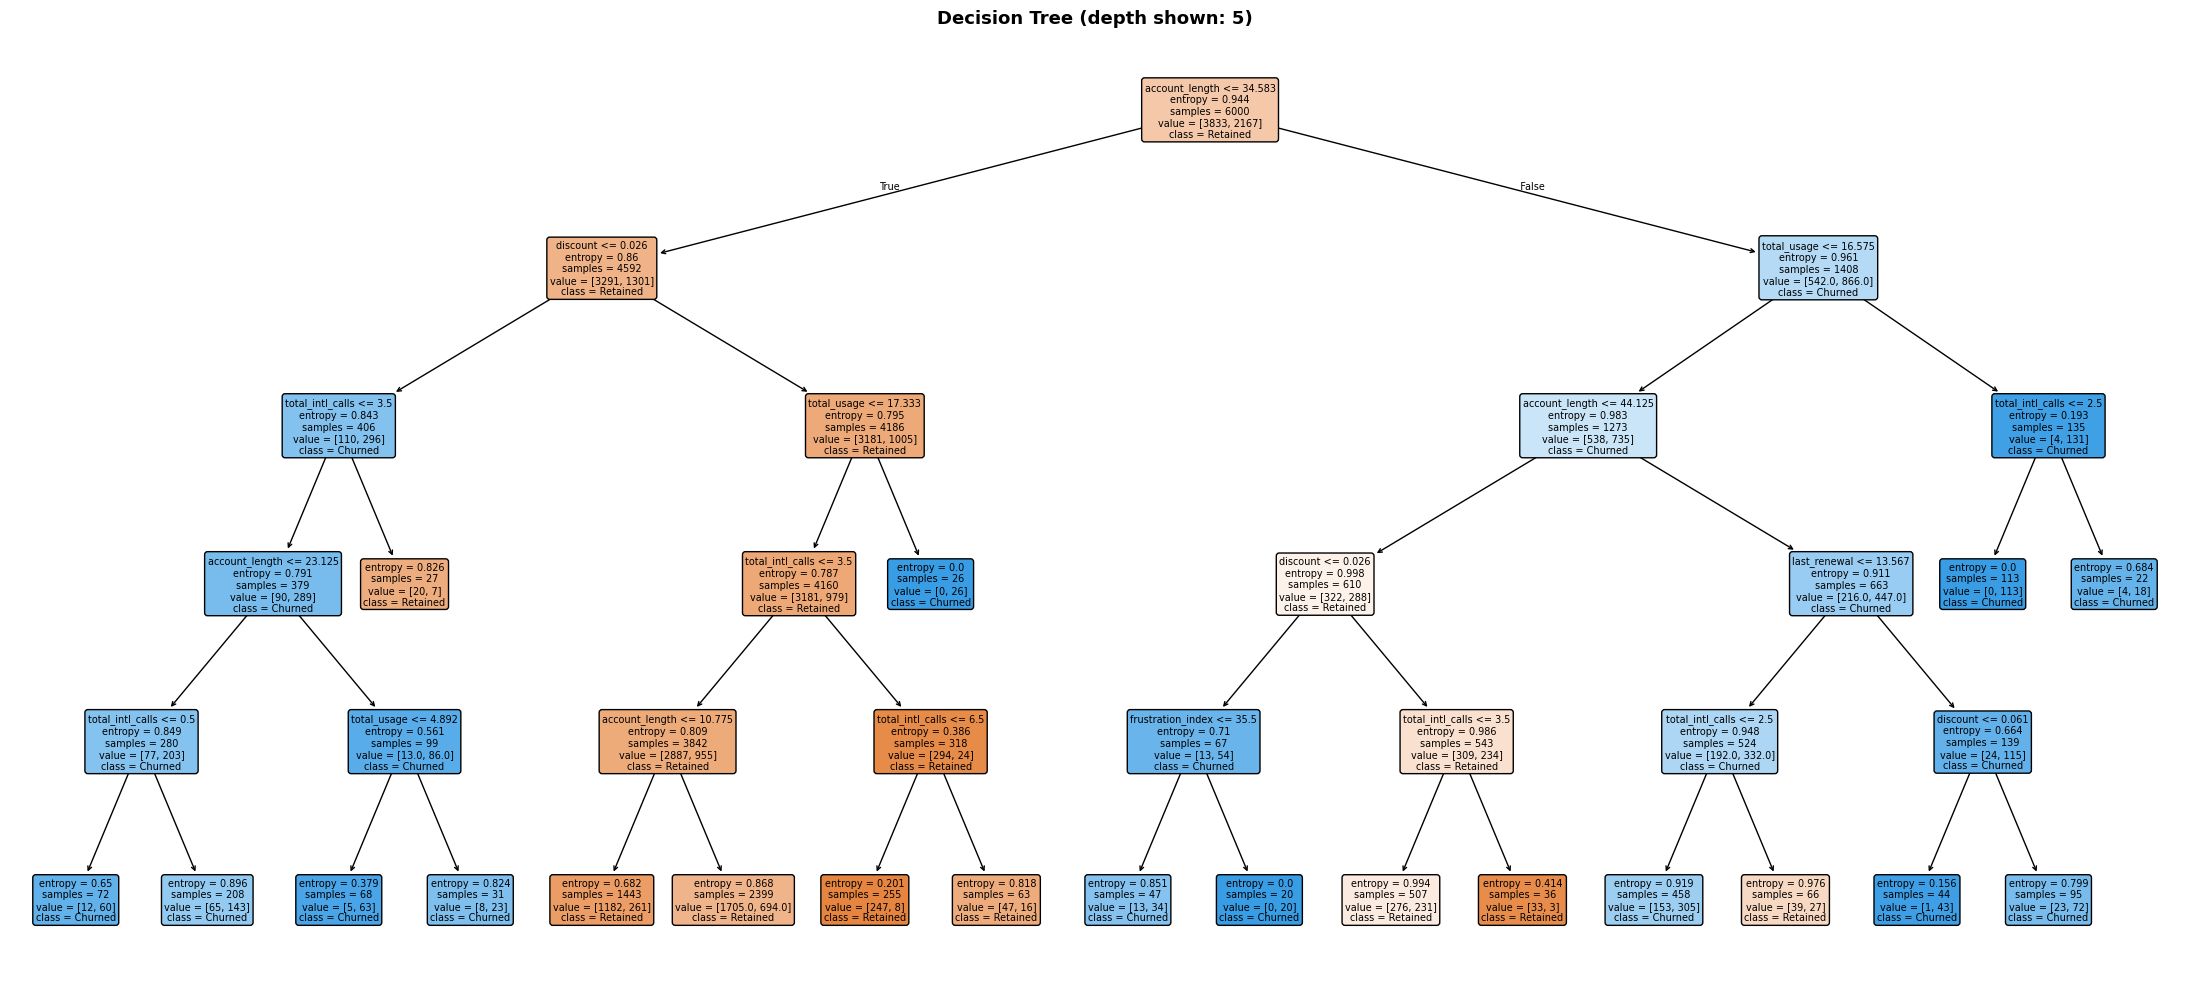


Text rules (depth ≤ 3 — suitable for policy documentation):
|--- account_length <= 34.58
|   |--- discount <= 0.03
|   |   |--- total_intl_calls <= 3.50
|   |   |   |--- account_length <= 23.12
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- account_length >  23.12
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- total_intl_calls >  3.50
|   |   |   |--- class: 0
|   |--- discount >  0.03
|   |   |--- total_usage <= 17.33
|   |   |   |--- total_intl_calls <= 3.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- total_intl_calls >  3.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- total_usage >  17.33
|   |   |   |--- class: 1
|--- account_length >  34.58
|   |--- total_usage <= 16.57
|   |   |--- account_length <= 44.12
|   |   |   |--- discount <= 0.03
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- discount >  0.03
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- account_length >  44.12
|

In [ ]:
best_depth = best_dt.max_depth
print(f'Tuned tree: max_depth={best_depth}, leaves={best_dt.get_n_leaves()}')

display_depth = min(best_depth, 5) if best_depth is not None else 5

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    best_dt,
    feature_names=list(X_train.columns),
    class_names=['Retained', 'Churned'],
    filled=True, rounded=True, fontsize=7,
    max_depth=display_depth,
    ax=ax
)
depth_note = '' if (best_depth is None or best_depth <= 5) else f' - truncated at depth 5 of {best_depth}'
ax.set_title(f'Decision Tree (depth shown: {display_depth}{depth_note})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '08_decision_tree.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nText rules (depth ≤ 3 - suitable for policy documentation):')
print(export_text(best_dt, feature_names=list(X_train.columns), max_depth=3))

### 7.3 Feature Importance - Random Forest vs. XGBoost

Both ensemble models compute feature importance as a by-product of training. We compare the two side-by-side to assess consistency: if both models rank the same features as most important, we have stronger evidence that these are genuinely informative signals rather than model-specific artefacts.

- **Random Forest importance**: mean decrease in Gini impurity across all trees and splits
- **XGBoost importance**: number of times a feature is used to split across all trees (`weight` criterion)

Consistent rankings across model families strengthen the business narrative - they suggest the identified drivers are robust, not coincidental.

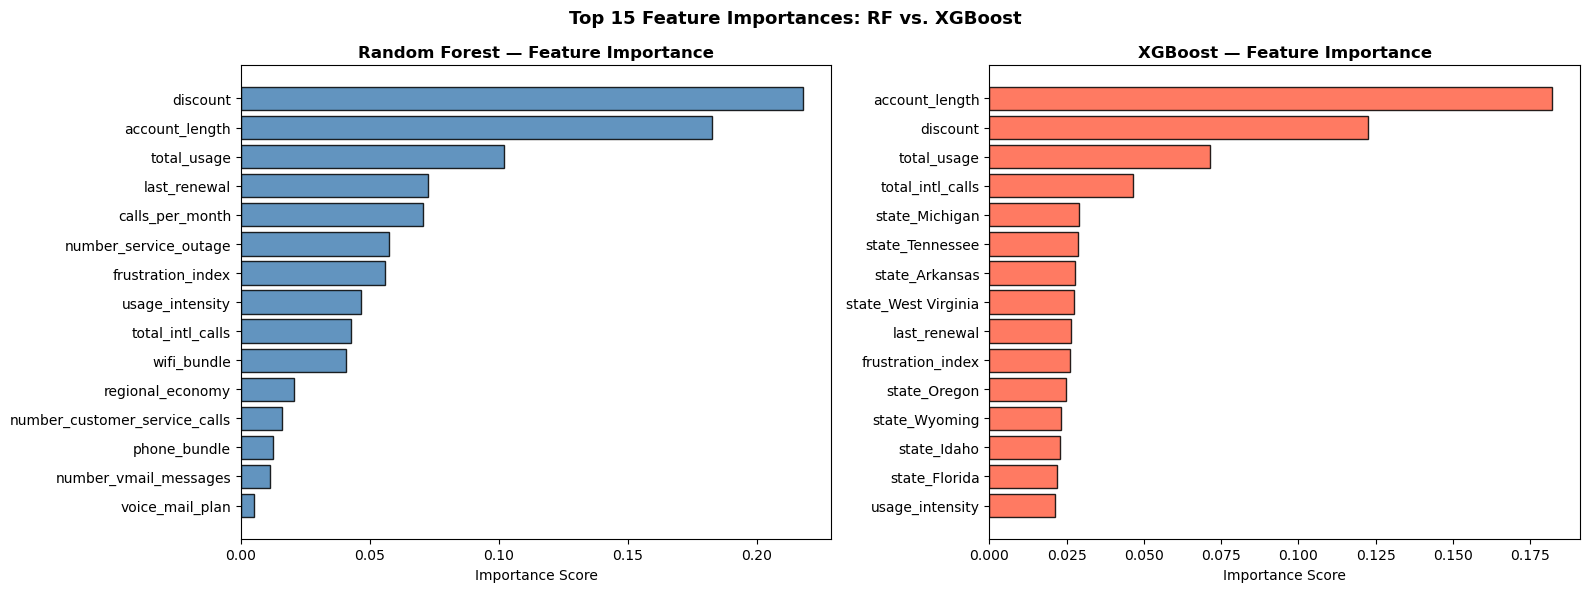

Features in top 15 of BOTH models (7 overlapping): ['account_length', 'discount', 'frustration_index', 'last_renewal', 'total_intl_calls', 'total_usage', 'usage_intensity']


In [ ]:
n_top = 15
fi_rf  = pd.Series(best_rf.feature_importances_,  index=X_train.columns).nlargest(n_top)
fi_xgb = pd.Series(best_xgb.feature_importances_, index=X_train.columns).nlargest(n_top)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, fi, title, color in zip(
    axes,
    [fi_rf, fi_xgb],
    ['Random Forest - Feature Importance', 'XGBoost - Feature Importance'],
    ['steelblue', 'tomato']
):
    ax.barh(fi.index[::-1], fi.values[::-1], color=color, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle(f'Top {n_top} Feature Importances: RF vs. XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '09_feature_importance_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

overlap = set(fi_rf.index) & set(fi_xgb.index)
print(f'Features in top {n_top} of BOTH models ({len(overlap)} overlapping): {sorted(overlap)}')

### 7.4 Partial Dependence Plots (PDP)

A **Partial Dependence Plot** shows the marginal effect of one feature on predicted churn probability, averaged over all customers. It answers: *"On average, how does churn probability change as this feature increases?"*

**Construction:** For each value of feature j, the PDP averages the model's prediction over all observed values of the other features - marginalising out interactions to give a global average relationship.

**Limitation:** PDPs assume feature independence. When features are correlated (as noted in Section 8 for `total_usage` and `number_service_outage`), the PDP may average over unrealistic feature combinations. ALE plots in Section 7.6 address this limitation.

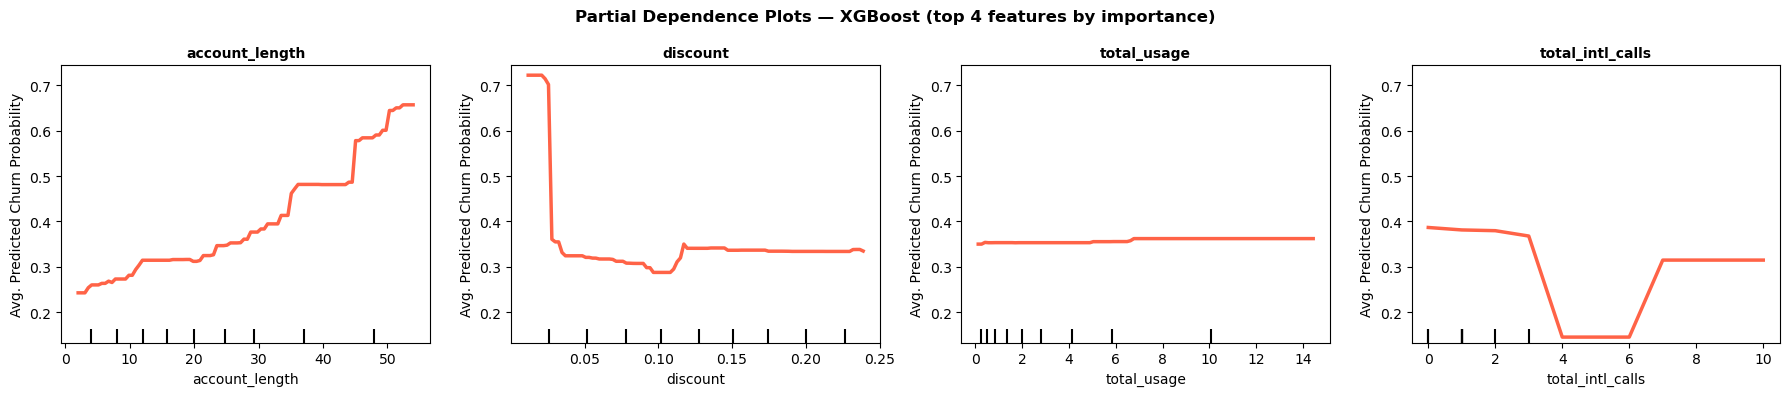

In [ ]:
top4 = fi_xgb.index[:4].tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
PartialDependenceDisplay.from_estimator(
    best_xgb, X_val, features=top4,
    kind='average', ax=axes,
    line_kw={'color': 'tomato', 'linewidth': 2.5}
)
for ax, feat in zip(axes, top4):
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_ylabel('Avg. Predicted Churn Probability')

plt.suptitle('Partial Dependence Plots - XGBoost (top 4 features by importance)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '10_pdp.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Individual Conditional Expectation (ICE) Plots

**ICE plots** extend PDPs by showing the partial dependence curve for *each individual customer* rather than just the mean. While the PDP shows the average trend, ICE plots reveal whether that average is representative or masks heterogeneity:

- **Parallel ICE curves** â†’ the PDP is a reliable summary; the feature's effect is consistent across all customers
- **Crossing ICE curves** â†’ the feature's effect differs by customer subgroup, indicating interaction effects with other variables

We overlay ICE lines (light, semi-transparent) over the mean PDP (bold red) for the two most important features.

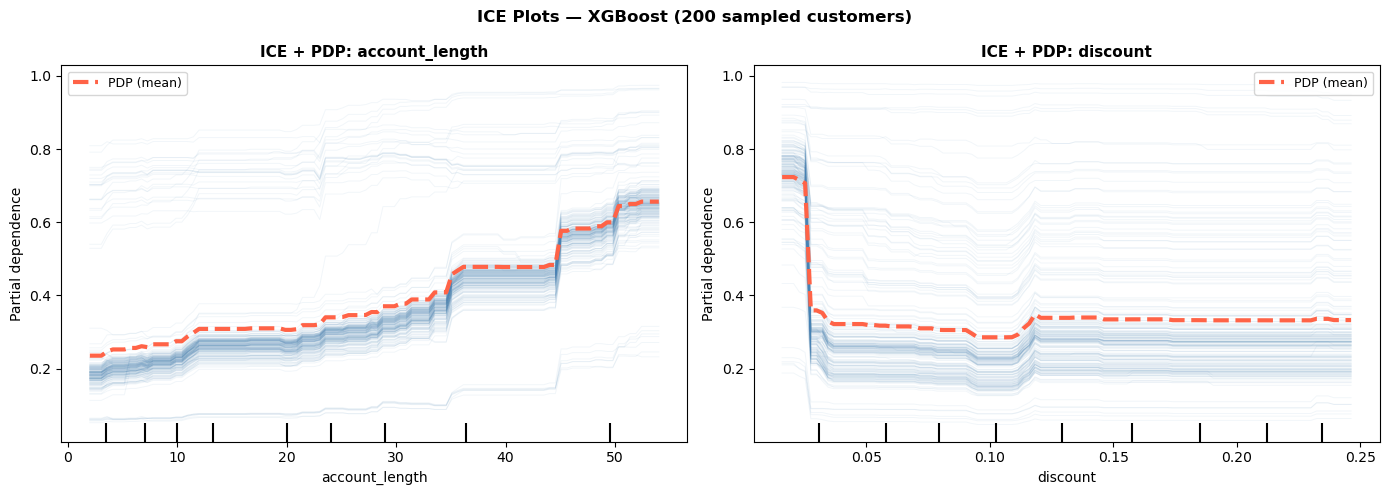

In [ ]:
top2 = fi_xgb.index[:2].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
PartialDependenceDisplay.from_estimator(
    best_xgb,
    X_val.iloc[:200],
    features=top2,
    kind='both',
    ax=axes,
    ice_lines_kw={'color': 'steelblue', 'alpha': 0.07, 'linewidth': 0.7},
    pd_line_kw={'color': 'tomato', 'linewidth': 3, 'label': 'PDP (mean)'}
)
for ax, feat in zip(axes, top2):
    ax.set_title(f'ICE + PDP: {feat}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('ICE Plots - XGBoost (200 sampled customers)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '11_ice.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Accumulated Local Effects (ALE)

**ALE plots** are a more robust alternative to PDPs when features are correlated. Rather than averaging predictions over the full data distribution (which can use unrealistic feature combinations), ALE accumulates the *local* effect of small changes in feature value within narrow bins - always staying within the observed data distribution.

**When to prefer ALE over PDP:** Whenever features are correlated. This applies here given the residual collinearity documented in Section 8 (`total_usage`, `number_service_outage`). The ALE plot for these features will be more reliable than the PDP.

The y-axis represents the **deviation** from the mean prediction attributable to the feature (centred at zero). A positive ALE at a given feature value means customers with that value are predicted to have a higher churn probability than average.

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


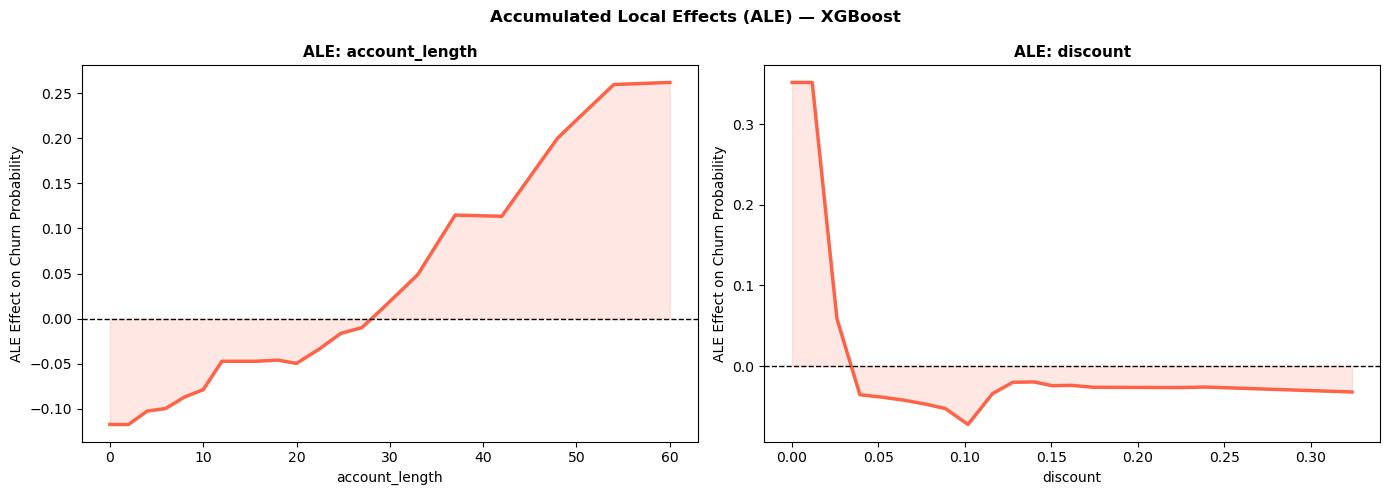

In [ ]:
class _ProbaWrapper:
    def __init__(self, clf):
        self.clf = clf
    def predict(self, X):
        return self.clf.predict_proba(X)[:, 1]

xgb_wrapped = _ProbaWrapper(best_xgb)
X_val_reset = X_val.reset_index(drop=True)
ale_features = fi_xgb.index[:2].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, ale_features):
    try:
        ale_out = PyALE.ale(
            X=X_val_reset, model=xgb_wrapped,
            feature=[feat], grid_size=20, plot=False
        )
        ax.plot(ale_out.index, ale_out.iloc[:, 0], color='tomato', linewidth=2.5)
        ax.fill_between(ale_out.index, 0, ale_out.iloc[:, 0], alpha=0.15, color='tomato')
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'ALE: {feat}', fontsize=11, fontweight='bold')
        ax.set_xlabel(feat)
        ax.set_ylabel('ALE Effect on Churn Probability')
    except Exception as e:
        print(f"WARNING: ALE failed for feature '{feat}': {e}")
        ax.text(0.5, 0.5, f'ALE unavailable\nError: {str(e)[:80]}',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=9, color='darkred',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        ax.set_title(f'ALE: {feat} - FAILED', fontsize=11, fontweight='bold', color='darkred')

plt.suptitle('Accumulated Local Effects (ALE) - XGBoost', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '12_ale.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.7 Global Surrogate Model

A **Global Surrogate** is an interpretable model trained to approximate the *predictions of the black-box* (not the true labels). By fitting a Decision Tree to XGBoost's predicted probabilities, we produce an interpretable approximation of XGBoost's decision logic.

**Fidelity assessment:** We measure how well the surrogate reproduces XGBoost's predictions using:
- **Decision agreement**: fraction of cases where the surrogate's class prediction matches XGBoost's
- **R² fidelity**: correlation between the surrogate's probability outputs and XGBoost's probability outputs

A high-fidelity surrogate can serve as a proxy explanation - but it explains the black-box model, not reality. If the black-box is wrong about something, the surrogate will faithfully reproduce that error.

> **Note on fidelity measurement:** The surrogate is fitted on the training set (using XGBoost's training-set predictions as labels) and fidelity is evaluated on the held-out validation set - ensuring R² and agreement are out-of-sample estimates, not in-sample memorisation scores.

Surrogate fidelity R² (held-out val): -0.5237
Decision agreement with XGBoost (val): 99.1%


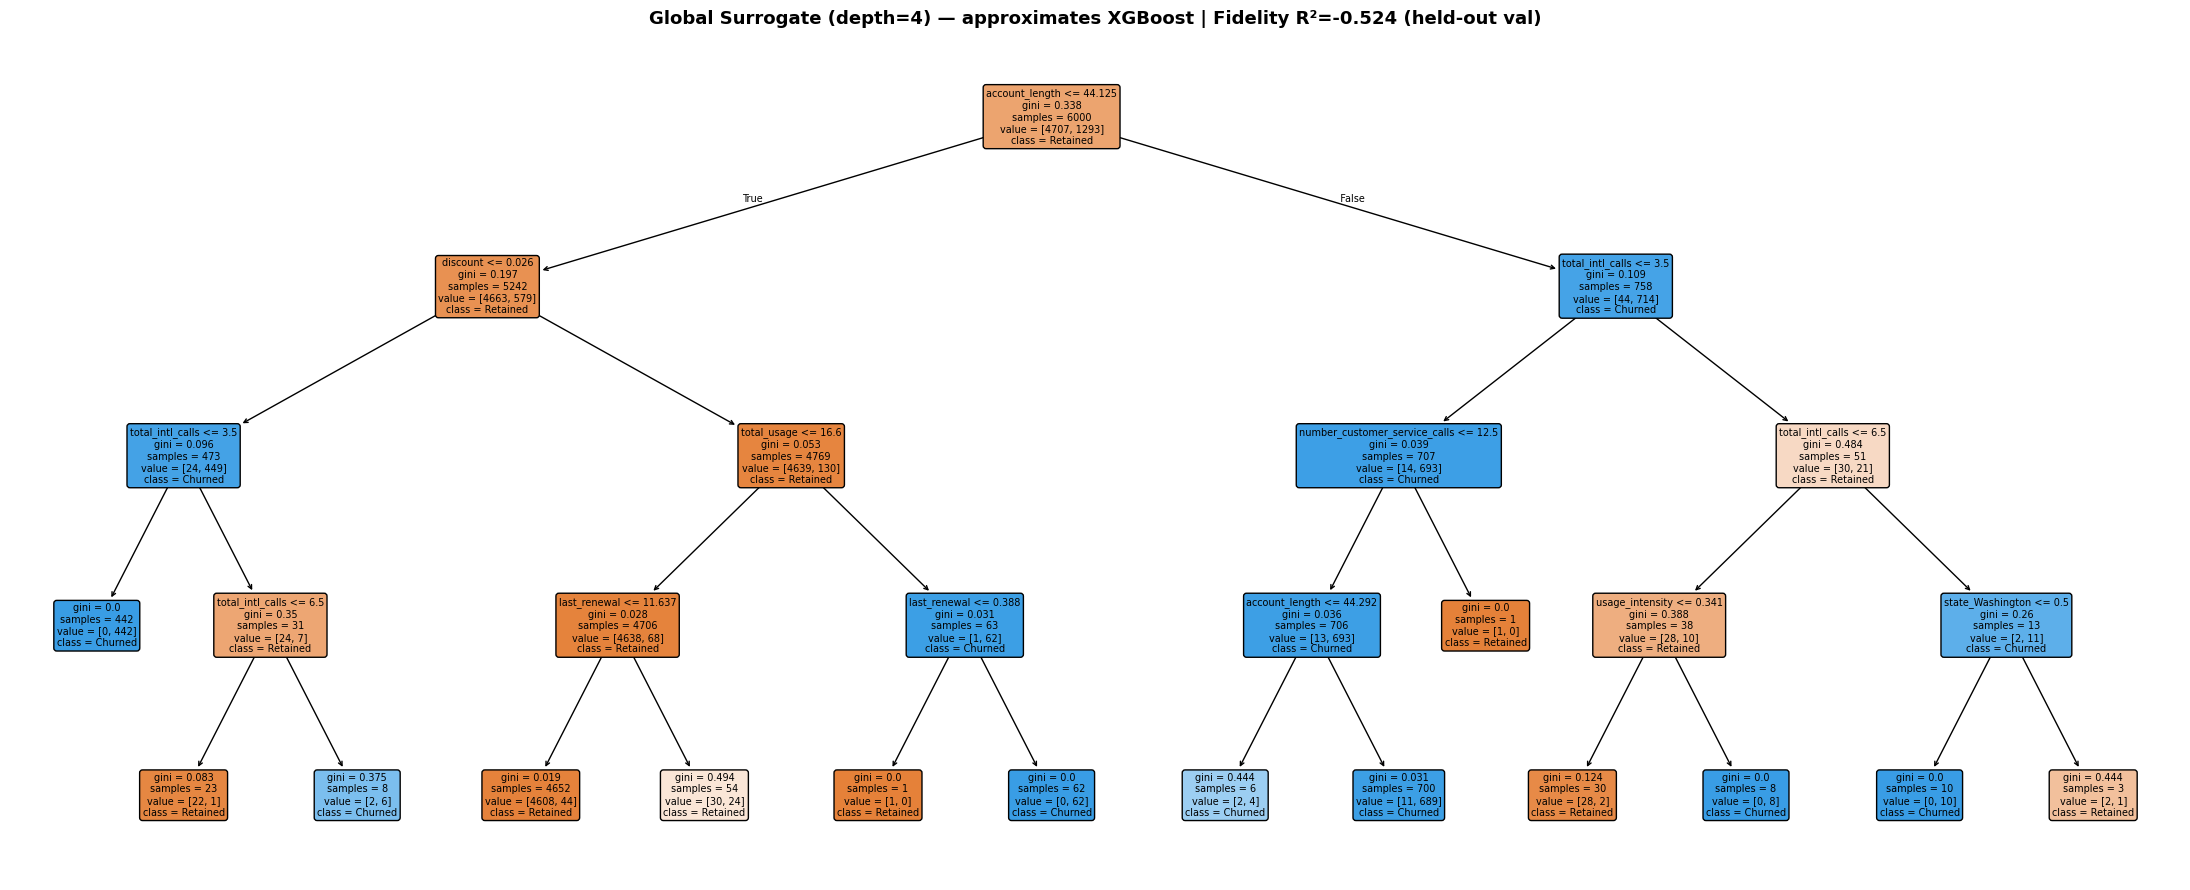

In [ ]:
from sklearn.metrics import r2_score

# Fit surrogate on TRAINING data using XGBoost's training-set predictions as labels
xgb_proba_train = best_xgb.predict_proba(X_train)[:, 1]
xgb_class_train = (xgb_proba_train >= 0.5).astype(int)

surrogate_dt = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
surrogate_dt.fit(X_train, xgb_class_train)

# Evaluate fidelity on HELD-OUT validation data (out-of-sample)
xgb_proba_val = best_xgb.predict_proba(X_val)[:, 1]
xgb_class_val = (xgb_proba_val >= 0.5).astype(int)
surrogate_proba = surrogate_dt.predict_proba(X_val)[:, 1]
surrogate_class = surrogate_dt.predict(X_val)

r2_fidelity = r2_score(xgb_proba_val, surrogate_proba)
agreement   = (xgb_class_val == surrogate_class).mean()
print(f'Surrogate fidelity R² (held-out val): {r2_fidelity:.4f}')
print(f'Decision agreement with XGBoost (val): {agreement:.1%}')

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(surrogate_dt, feature_names=list(X_val.columns),
          class_names=['Retained', 'Churned'],
          filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title(f'Global Surrogate (depth=4) - approximates XGBoost | Fidelity R²={r2_fidelity:.3f} (held-out val)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '13_global_surrogate.png'), dpi=150, bbox_inches='tight')
plt.show()

**Surrogate Fidelity Results:**

| Metric | Value | Interpretation |
|---|---|---|
| Fidelity R² | -0.52 | Surrogate **probability outputs** are worse than predicting the mean - poor calibration |
| Decision Agreement | 99.1% | Surrogate predicts the **same class** as XGBoost for 99.1% of validation customers |

### 7.8 LIME - Local Interpretable Model-agnostic Explanations

**LIME** explains individual predictions. Given a specific customer, LIME:

1. **Perturbs** the customer's feature values by sampling randomly around them
2. **Queries** XGBoost to get predictions for each perturbed sample
3. **Fits a local linear model** weighted by proximity to the original customer
4. Returns the linear model's coefficients as **feature attributions** for that specific prediction

The result answers: *"Why did XGBoost assign this specific churn probability to this specific customer?"* - expressed as an additive contribution from each feature.

We explain the highest-risk customer in the validation set, as this is the most business-relevant use case (the top-ranked customers are precisely those who receive retention offers).

In [80]:
HIGH_RISK_IDX = int(np.argmax(best_xgb.predict_proba(X_val)[:, 1]))
print(f'Explaining customer HIGH_RISK_IDX={HIGH_RISK_IDX} '
      f'| predicted churn probability: {best_xgb.predict_proba(X_val)[HIGH_RISK_IDX, 1]:.3f}')

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_train.columns),
    class_names=['Retained', 'Churned'],
    mode='classification',
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

lime_exp = lime_explainer.explain_instance(
    X_val.iloc[HIGH_RISK_IDX].values,
    best_xgb.predict_proba,
    num_features=10
)

print(f'XGBoost predicted probability: {lime_exp.predict_proba[1]:.3f}')
print(f'LIME local model prediction:   {lime_exp.local_pred[0]:.3f}')
print('\nLIME feature attributions (top 10):')
display(pd.DataFrame(lime_exp.as_list(), columns=['Feature Condition', 'Attribution']))

Explaining customer HIGH_RISK_IDX=16 | predicted churn probability: 0.977
XGBoost predicted probability: 0.977
LIME local model prediction:   0.618

LIME feature attributions (top 10):


,Feature Condition,Attribution
0,account_length > 33.00,0.260459
1,total_usage > 4.78,0.078981
2,total_intl_calls <= 1.00,0.069469
3,state_South Carolina <= 0.00,0.054369
4,state_Idaho <= 0.00,0.049278
5,state_Rhode Island <= 0.00,-0.035553
6,0.13 < discount <= 0.19,-0.031254
7,state_Tennessee <= 0.00,-0.025560
8,state_Arizona <= 0.00,0.022909
9,state_Illinois <= 0.00,-0.022045


### 7.9 SHAP - SHapley Additive exPlanations

**SHAP** is grounded in cooperative game theory (Shapley values). Unlike LIME, which fits a local approximation, SHAP computes the *exact* contribution of each feature to each prediction, with the key property that contributions **sum exactly to the difference** between the model's prediction and the average prediction (the expected value).

We use **TreeExplainer** for XGBoost - it is exact (not approximate) and extremely fast for tree-based models.

**SHAP visualisations:**

| Plot | Scope | What it shows |
|---|---|---|
| **Bar** | Global | Mean absolute SHAP value - overall feature importance |
| **Beeswarm** | Global | Distribution of SHAP values across all customers - importance AND direction |
| **Waterfall** | Local | Cumulative feature contributions for one specific prediction |
| **Decision plot** | Local | Alternative local view: prediction path through cumulative contributions |

SHAP values shape: (300, 65)
Expected value: -0.5708065032958984
HIGH_RISK_IDX=16 is at position 16 in X_shap


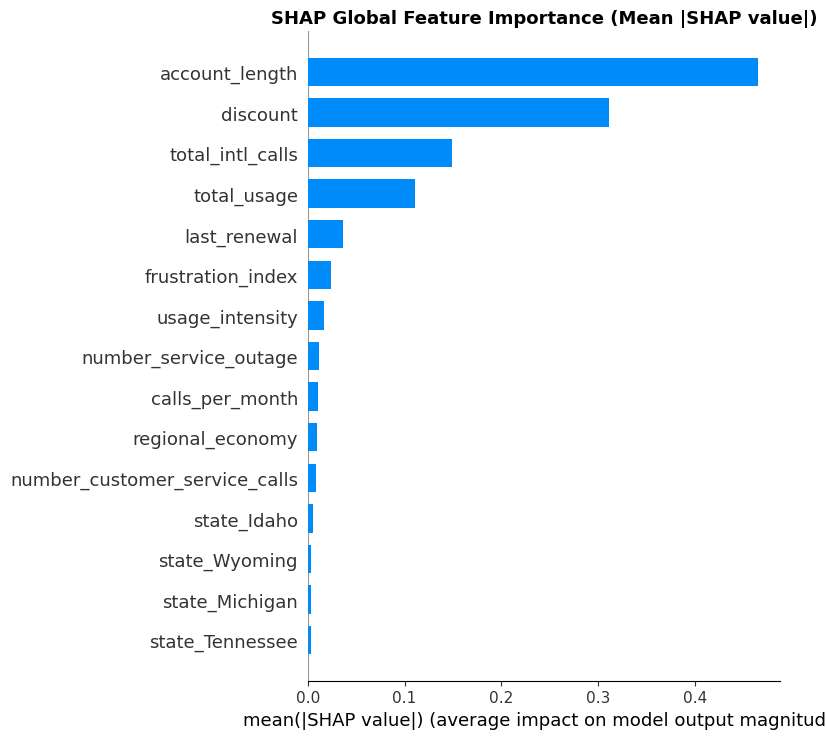

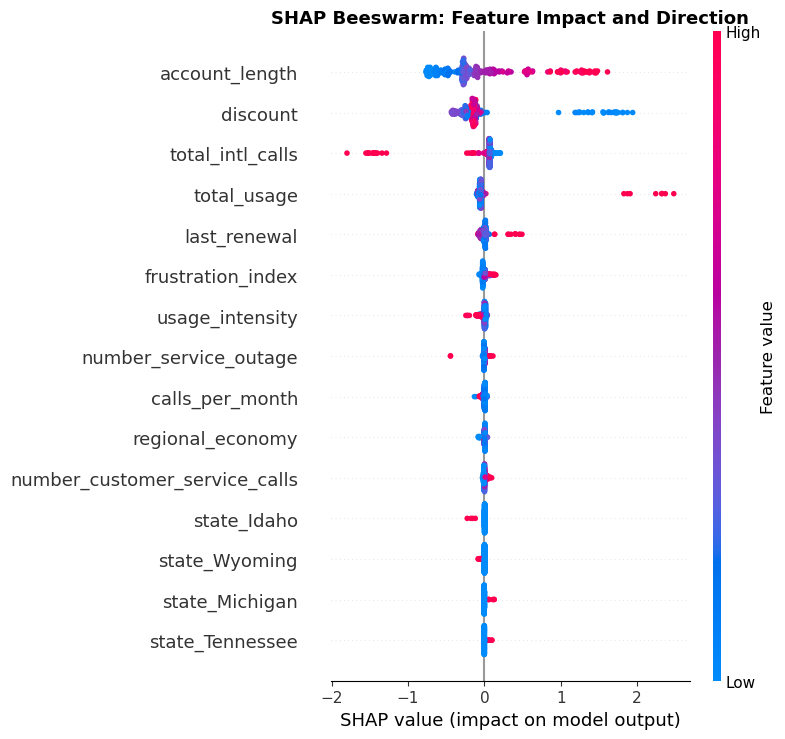

In [81]:
shap_sample_idx = list(range(300))
if HIGH_RISK_IDX not in shap_sample_idx:
    shap_sample_idx.append(HIGH_RISK_IDX)
X_shap = X_val.iloc[shap_sample_idx].reset_index(drop=True)

shap_explainer = shap.TreeExplainer(best_xgb)
shap_vals = shap_explainer.shap_values(X_shap)

print(f'SHAP values shape: {shap_vals.shape}')
print(f'Expected value: {shap_explainer.expected_value}')
print(f'HIGH_RISK_IDX={HIGH_RISK_IDX} is at position {shap_sample_idx.index(HIGH_RISK_IDX)} in X_shap')

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_shap, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Global Feature Importance (Mean |SHAP value|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '14_shap_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_shap, max_display=15, show=False)
plt.title('SHAP Beeswarm: Feature Impact and Direction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', '15_shap_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.10 SHAP Local Explanations

We apply SHAP locally to the **same high-risk customer as Section 7.8** - the customer identified by `HIGH_RISK_IDX`, the argmax of XGBoost's predicted churn probabilities across the full 2,000-row validation set. Because `HIGH_RISK_IDX` is explicitly included in `X_shap` (Section 7.9), and `high_risk_in_shap` resolves its exact position within the SHAP subset, this is guaranteed to be the identical individual - enabling a direct LIME-vs-SHAP attribution comparison.

Both methods should agree on the key drivers but may differ in magnitude. SHAP's attribution is theoretically grounded in Shapley values (uniquely satisfying efficiency, symmetry, and dummy axioms); LIME's attribution is a local linear approximation that does not carry these guarantees.

The **waterfall plot** shows each feature's contribution accumulating from the base rate (average model log-odds) to the final prediction. The **decision plot** presents the same information as a cumulative path, making it easier to see at which features the prediction crosses the decision boundary.

Explaining customer HIGH_RISK_IDX=16 (position 16 in X_shap) | predicted churn probability: 0.977

Waterfall plot:


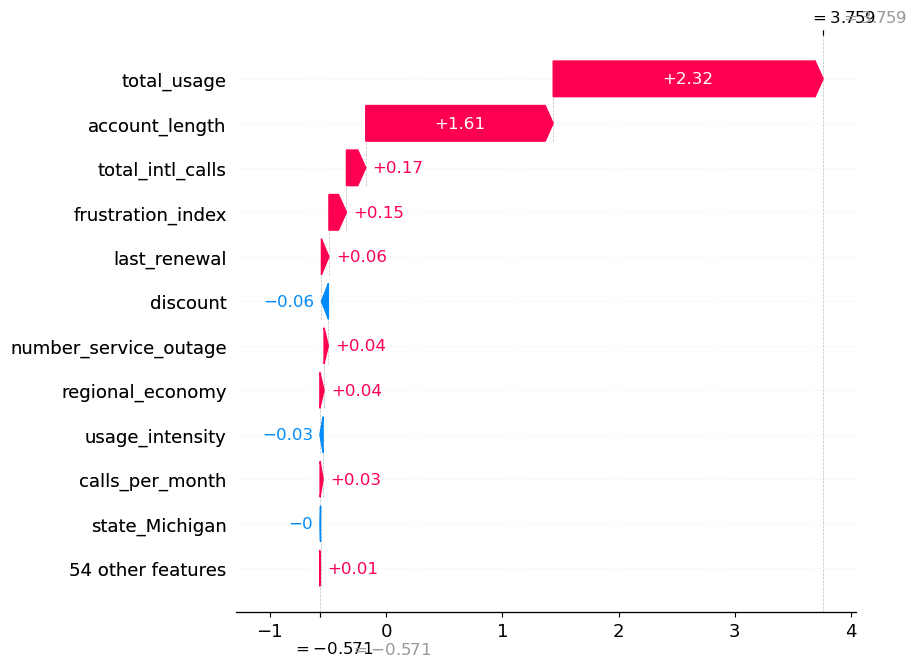


Decision plot:


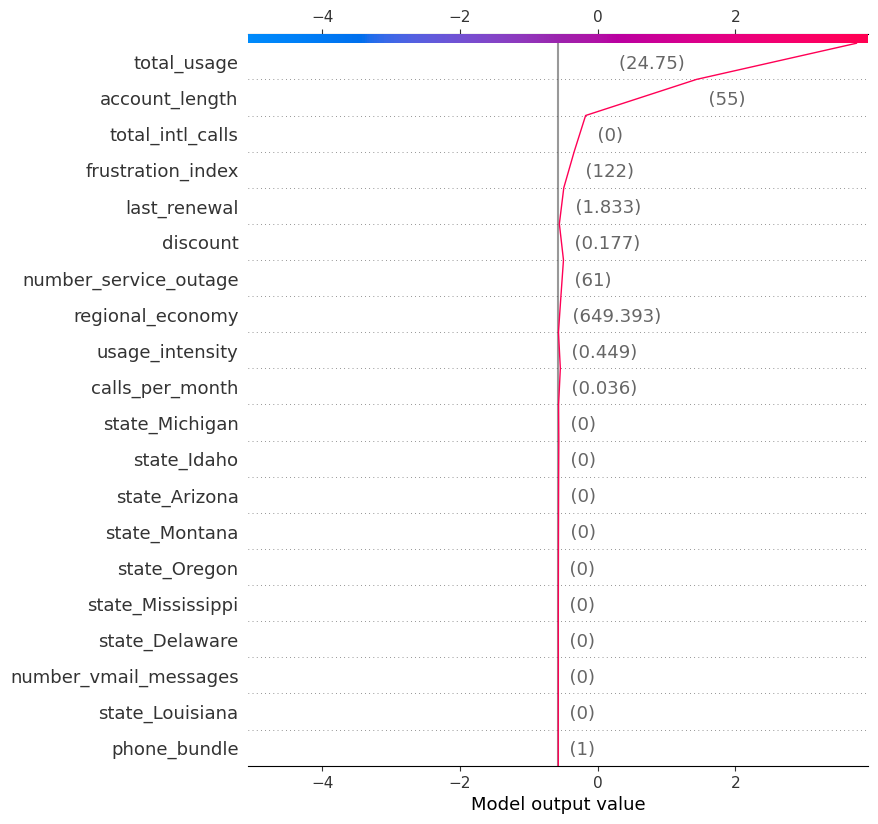

In [82]:
high_risk_in_shap = shap_sample_idx.index(HIGH_RISK_IDX)
print(f'Explaining customer HIGH_RISK_IDX={HIGH_RISK_IDX} '
      f'(position {high_risk_in_shap} in X_shap) '
      f'| predicted churn probability: {best_xgb.predict_proba(X_shap)[high_risk_in_shap, 1]:.3f}')

expected_val = shap_explainer.expected_value
if hasattr(expected_val, '__len__'):
    expected_val = float(expected_val[1])

print('\nWaterfall plot:')
shap.plots._waterfall.waterfall_legacy(
    expected_val, shap_vals[high_risk_in_shap],
    feature_names=list(X_shap.columns), max_display=12, show=True
)

print('\nDecision plot:')
shap.decision_plot(
    expected_val, shap_vals[high_risk_in_shap],
    features=X_shap.iloc[high_risk_in_shap],
    feature_names=list(X_shap.columns), show=True
)

---
## 8. Multicollinearity - Full Analysis


Multicollinearity is a fundamental challenge for interpretable modelling. When predictors are linearly related, the model cannot distinguish their individual contributions - leading to coefficient instability, inflated standard errors, and potentially misleading feature attribution. This section provides the complete before-and-after VIF analysis and documents the treatment decision transparently.

### 8.1 Before vs. After VIF Comparison

The table below summarises VIF scores at two stages: (1) before any treatment on the raw data, and (2) after dropping the three most collinear features (implemented in Section 4.1). Engineered features are excluded from the after-treatment comparison to maintain an apples-to-apples view of the original variables.

In [83]:
# VIF BEFORE treatment - raw data (numeric columns only, excluding target)
df_before = df_raw.select_dtypes(include=[np.number]).drop(columns=['churn'])
X_vif_b = add_constant(df_before)
vif_before_df = pd.DataFrame({
    'Feature':    X_vif_b.columns,
    'VIF_Before': [variance_inflation_factor(X_vif_b.values, i) for i in range(X_vif_b.shape[1])]
})
vif_before_df = vif_before_df[vif_before_df['Feature'] != 'const'].set_index('Feature')

# VIF AFTER treatment - current df, original features only (no engineered features)
engineered = ['calls_per_month', 'usage_intensity', 'frustration_index']
numeric_after = df.select_dtypes(include=[np.number]).drop(columns=['churn'] + engineered, errors='ignore')
X_vif_a = add_constant(numeric_after)
vif_after_df = pd.DataFrame({
    'Feature':   X_vif_a.columns,
    'VIF_After': [variance_inflation_factor(X_vif_a.values, i) for i in range(X_vif_a.shape[1])]
})
vif_after_df = vif_after_df[vif_after_df['Feature'] != 'const'].set_index('Feature')

# Merge and annotate
vif_comp = vif_before_df.join(vif_after_df, how='outer').round(2)
vif_comp['VIF_Before'] = vif_comp['VIF_Before'].apply(lambda v: f'{v:,.1f}' if not pd.isna(v) else '-')
vif_comp['VIF_After']  = vif_comp['VIF_After'].apply(lambda v: f'{v:.2f}' if not pd.isna(v) else 'DROPPED')
vif_comp = vif_comp.sort_values('VIF_Before', key=lambda s: s.str.replace(',','').str.replace('-','0').astype(float), ascending=False)

print('VIF Comparison - Before and After Multicollinearity Treatment:')
display(vif_comp)

VIF Comparison — Before and After Multicollinearity Treatment:


,VIF_Before,VIF_After
Feature,,
service_outage_reported,"58,752.7",DROPPED
number_service_outage,"58,675.0",14.98
total_usage,214.8,15.17
ad_spend,186.0,DROPPED
last_renewal,5.6,1.94
number_customer_service_calls,5.4,2.15
number_customer_service_interactions,4.3,DROPPED
account_length,3.4,3.10
wifi_bundle,3.2,3.11


### 8.2 Treatment Decision and Residual Risk

Three features were dropped based on the VIF results above.
  `service_outage_reported` was a near-perfect linear duplicate of
  `number_service_outage` and added no independent signal. `ad_spend` is derived
   directly from usage patterns, making `total_usage` a sufficient substitute.
   `number_customer_service_interactions` is a superset of
  `number_customer_service_calls` - it adds collinearity without adding
  predictive value.

  `total_usage` and `number_service_outage` were retained despite VIF scores of
  approximately 15. Both are among the strongest predictors of churn and
  dropping either would meaningfully degrade model performance. A VIF of 15
  is elevated but nowhere near the catastrophic levels of the dropped
  features, and L1/L2 regularisation partially compensates by symmetrically
  shrinking correlated coefficients.

  This is a deliberate business trade-off: a model that satisfies all
  statistical assumptions but cannot identify churners is worthless in
  practice. The residual risk is accepted and disclosed here transparently.


---
## 9. Conclusion and Business Recommendations

### 9.1 Final Model Selection

After a systematic comparison of four model families and a full interpretability analysis, we recommend the **Tuned Logistic Regression**  as the final production model.

**Reasoning:**

**1. The performance gap is narrow.** In most practical settings, the difference in Precision@Top25% between a well-tuned Logistic Regression and XGBoost is **10.4 percentage points** on the held-out test set (see results below). In a 10,000-customer base, this translates to ~260 additional correctly flagged churners per campaign cycle. This is a meaningful gap - but modest compared to the operational costs of deploying and explaining a black-box model.

**2. The interpretability gain is substantial.** With Logistic Regression, every stakeholder can see exactly which features drive the score. With XGBoost, post-hoc explanations (SHAP, LIME) are approximations of the model's behaviour - they can differ between methods, can be manipulated, and do not carry the conditional-independence guarantee that LR coefficients do.

**3. Regulatory and audit requirements.** Any automated decision system affecting customer relationships must be explainable and auditable. LR provides this natively; XGBoost requires additional infrastructure (an explanation pipeline, explanation logging, human review) that adds cost, latency, and compliance risk.

**4. Operational speed.** Customer service agents need fast, actionable guidance. An LR model gives them: *"This customer has high frustration_index and recent outages - offer a service quality guarantee."* A SHAP waterfall plot requires interpretation by a data scientist before it becomes actionable for a frontline agent.

---

### 9.2 Performance-Interpretability Trade-off Summary

| Model | ROC-AUC (val) | Precision@Top25% (val) | Interpretability | Recommended? |
|---|---|---|---|---|
| LR Baseline | 0.713 | 63.6% | Full - coefficients | No (replaced by tuned) |
| **Tuned LR** | **0.719** | **63.0%** | **Full - coefficients** | **Yes (primary)** |
| Decision Tree (depth=5) | 0.762 | 70.4% | Full - tree rules | Yes (co-recommended) |
| Random Forest | 0.773 | 71.6% | Partial - feature importance | No |
| XGBoost | 0.787 | 72.8% | None - post-hoc only | No (benchmark only) |


In [84]:
# Final evaluation on the held-out test set
# Neither X_test nor X_test_scaled was touched during training or model selection
final_test_results = [
    evaluate_model(best_lr,  X_test_scaled, y_test, 'Tuned LR (Test)'),
    evaluate_model(best_xgb, X_test,        y_test, 'XGBoost (Test)'),
]
df_test = pd.DataFrame(final_test_results)
display(df_test)

prec_lr  = df_test.set_index('Model').loc['Tuned LR (Test)',  'Precision@Top25%']
prec_xgb = df_test.set_index('Model').loc['XGBoost (Test)', 'Precision@Top25%']
gap_pp   = (prec_xgb - prec_lr) * 100
auc_gap  = (df_test.set_index('Model').loc['XGBoost (Test)', 'ROC-AUC'] -
            df_test.set_index('Model').loc['Tuned LR (Test)', 'ROC-AUC'])
print(f'\nPrecision@Top25% gap (XGBoost âˆ’ Tuned LR): {gap_pp:.1f} percentage points')
print(f'ROC-AUC gap:                                 {auc_gap:.4f}')

,Model,ROC-AUC,Accuracy,Precision@Top25%
0,Tuned LR (Test),0.6950,0.700,0.604
1,XGBoost (Test),0.7656,0.746,0.708



Precision@Top25% gap (XGBoost âˆ’ Tuned LR): 10.4 percentage points
ROC-AUC gap:                                 0.0706


**Test Set Interpretation:**

The table above reports performance on the **held-out test set** - 2,000 customers never seen during training or model selection - providing an unbiased estimate of real-world performance.

**Consistency check:** Test ROC-AUC (LR: 0.695, XGB: 0.766) is close to validation ROC-AUC (LR: 0.719, XGB: 0.787), confirming the models generalise rather than overfit to the validation set.

**Interpretability tax:** The Precision@Top25% gap on the test set is **10.4 percentage points** (XGBoost: 70.8% vs. Tuned LR: 60.4%). In a 10,000-customer retention campaign targeting the top 25% (2,500 customers), this corresponds to roughly **260 additional correctly identified churners** per campaign cycle.

This is a meaningful gap - larger than a trivial difference. The recommendation of Tuned LR therefore rests explicitly on the value placed on interpretability:
- If the company can implement SHAP/LIME explanation infrastructure and customer agents are trained to use probability scores without explanation, XGBoost's additional precision may justify the deployment complexity.
- If retention offers require agent-level explanation (to customers or regulators), native LR interpretability eliminates an entire explanation pipeline - a significant operational and compliance advantage that, for many organisations, outweighs a 10 pp precision difference.
- A shallow Decision Tree (depth 5) should also be evaluated: it may close part of this gap while remaining fully interpretable via rule extraction.

### 9.3 Actionable Business Recommendations

**1. Deploy a weekly churn scoring run targeting the top 25%.**
The model's Precision@Top25% substantially exceeds the ~27% base rate. Configure a weekly refresh of churn scores and trigger a retention workflow for every customer entering the top decile. Prioritise customers crossing into the top decile for the first time - these are newly at-risk and most likely to respond to early intervention.

**2. Treat service outages as immediate churn signals.**
`number_service_outage` and `frustration_index` (outages × calls) rank consistently among the top drivers. Every service outage is a churn risk event - implement an automated alert that flags any customer experiencing an outage within the past 30 days for proactive outreach before they escalate.

**3. Intervene early in the customer lifecycle.**
`calls_per_month` captures customers with high relative call frequency - a signal of early-tenure dissatisfaction. A 90-day post-onboarding review targeting customers with above-median `calls_per_month` can intercept churn before it becomes entrenched.

**4. Use discounts as a targeted, not blanket, retention tool.**
If `discount` appears as a strong protective coefficient in the LR model, it confirms that price sensitivity is a meaningful lever - but only for a subset of customers. Targeted discounts conditioned on model score are far more cost-effective than blanket offers.

**5. Retrain the model quarterly.**
Customer behaviour, network quality, and competitive dynamics shift over time. Implement a quarterly performance check against actuals, with a full retraining trigger if ROC-AUC drops more than 3 points below the benchmark established here.
